# BINF 4002 — Machine Learning for Biomedical Data
## Homework Assignment: End-to-End ML Across Biomedical Domains

**Total Points: 100** (select any **two** of the three problems for grading; the third is optional bonus worth up to 10 extra-credit points)

| Problem | Domain | Points |
|---------|--------|--------|
| **Problem 1** | Biology — Pan-Cancer Gene Expression Classification | 50 |
| **Problem 2** | Clinical/EHR — Preventive Screening Compliance Prediction | 50 |
| **Problem 3** | Public Health — Influenza Forecasting | 50 |

### Instructions
1. **Choose two** problems to submit for grading.
2. You may complete the third for **up to 10 bonus points**.
3. All code must run **end-to-end in Google Colab**.
4. You are **encouraged** to use GenAI tools (Gemini, ChatGPT, Claude, Copilot) to understand concepts, debug, and implement. However, you must:
   - Understand and be able to explain every line of your code.
   - Write all discussion answers in your own words with genuine analytical depth.
   - **Submit a link to your primary GenAI conversation(s)** used during this assignment (e.g., a shared ChatGPT/Claude conversation link). This is for transparency, not penalization.
6. Submit this notebook as a `.ipynb` file with all cells executed and outputs visible.

### What we expect

Beyond working code and results, we expect you to think out loud throughout your notebook. In the problems below, comment on your model's performance across all relevant axes: not just a single number.

- What concerns would you have about adapting these results to a real-world setting?
- How would you extend your approach given more time or data, and what barriers would you expect?
- What trade-offs exist in your design choices, and why did you resolve them the way you did?

A notebook that achieves modest results but demonstrates genuine understanding will score higher than one with strong numbers and no interpretation.

In [1]:
# ============================================================
# PASTE YOUR GenAI CONVERSATION LINK(S) HERE
# ============================================================
GENAI_LINKS = [
    # "https://chatgpt.com/share/...",
    # "https://claude.ai/share/...",
    "https://chatgpt.com/g/g-p-69e81cc153288191bc17e5255be8c665" # The project link contain all chats with ChatGPT for this HW
    "https://claude.ai/share/ac3075a7-edc8-437f-98a7-09717689c50e" # Claude chat for Q2
]


---
## Environment Setup (Run First)


In [2]:
# ============================================================
# SHARED DEPENDENCIES — run this cell once
# ============================================================
!pip install -q scikit-learn pandas numpy matplotlib seaborn umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("✅ All shared dependencies loaded.")


✅ All shared dependencies loaded.


# Problem 1 Skipped

---
---
# Problem 1: Pan-Cancer Gene Expression Classification

## Background
RNA sequencing (RNA-Seq) measures the expression levels of thousands of genes simultaneously, producing a molecular "fingerprint" of a tissue sample. Different cancer types originate from different tissues and harbor distinct transcriptomic programs. In this problem, you will build a classifier that predicts cancer type from gene expression profiles, exploring how dimensionality reduction affects performance in a high-dimensional, low-sample-size (p >> n) setting.

## Dataset
The **UCI ML Gene Expression Cancer RNA-Seq** dataset contains 801 samples across 5 cancer types (BRCA, KIRC, LUAD, PRAD, COAD) with 20,531 gene expression features (RSEM normalized counts).

## Learning Objectives
- Handle extreme high-dimensionality (p >> n)
- Compare dimensionality reduction strategies
- Perform stratified cross-validation with class imbalance
- Interpret model outputs in biological context

---


## 1.1 Dataset Loading & Initial Inspection (5 pts)

In [3]:
# ============================================================
# 1.1 LOAD THE DATASET
# ============================================================
# Download the TCGA PANCAN RNA-Seq dataset (801 samples, 20531 genes, 5 cancer types)
# Source: UCI ML Repository — direct archive download

import os, tarfile, glob, shutil

DATA_DIR = '/content/pancan_data'
os.makedirs(DATA_DIR, exist_ok=True)

data_csv = os.path.join(DATA_DIR, 'data.csv')
labels_csv = os.path.join(DATA_DIR, 'labels.csv')

if not os.path.exists(data_csv):
    print("📥 Downloading TCGA PANCAN dataset...")

    # Primary source: UCI archive
    !wget -q --show-progress \
        "https://web.archive.org/web/20250330202645id_/https://archive.ics.uci.edu/ml/machine-learning-databases/00401/TCGA-PANCAN-HiSeq-801x20531.tar.gz" \
        -O /content/pancan.tar.gz

    # Extract (the tar.gz contains a nested structure)
    print("📦 Extracting...")
    with tarfile.open('/content/pancan.tar.gz', 'r:gz') as outer:
        outer.extractall('/content/pancan_tmp')

    # Handle nested tar files
    for t in glob.glob('/content/pancan_tmp/**/*.tar', recursive=True):
        with tarfile.open(t, 'r') as inner:
            inner.extractall(DATA_DIR)

    # Also move any CSVs found at top level
    for f in glob.glob('/content/pancan_tmp/**/*.csv', recursive=True):
        shutil.copy(f, DATA_DIR)

    # Verify extraction worked
    found = os.listdir(DATA_DIR)
    print(f"  Extracted: {found}")

    if not os.path.exists(data_csv):
        # Try to find the files with any name
        csvs = [f for f in found if f.endswith('.csv')]
        for f in csvs:
            fp = os.path.join(DATA_DIR, f)
            # data file is large (~70MB), labels is small
            size = os.path.getsize(fp) / 1e6
            if size > 10:
                shutil.copy(fp, data_csv)
                print(f"  Mapped {f} ({size:.0f}MB) → data.csv")
            else:
                shutil.copy(fp, labels_csv)
                print(f"  Mapped {f} ({size:.2f}MB) → labels.csv")

    assert os.path.exists(data_csv), (
        "❌ data.csv not found after extraction. "
        "Please download manually from:\n"
        "https://archive.ics.uci.edu/dataset/401/gene+expression+cancer+rna+seq\n"
        "and upload data.csv + labels.csv to /content/pancan_data/"
    )
    print("✅ Download complete!")
else:
    print("✅ Dataset already downloaded.")

# --- Load ---
X_raw = pd.read_csv(data_csv, index_col=0)
y_series = pd.read_csv(labels_csv, index_col=0)
y_raw = y_series.iloc[:, 0]

print(f"\nFeature matrix shape: {X_raw.shape}")
print(f"Target distribution:\n{y_raw.value_counts()}")
print(f"\nFirst 5 gene columns: {list(X_raw.columns[:5])}")
print(f"Any missing values in X: {X_raw.isnull().any().any()}")
print(f"Any missing values in y: {y_raw.isnull().any()}")


📥 Downloading TCGA PANCAN dataset...
/content/pancan.tar     [          <=>       ]  69.48M  32.8MB/s    in 2.1s    
📦 Extracting...
  Extracted: ['labels.csv', 'data.csv']
✅ Download complete!

Feature matrix shape: (801, 20531)
Target distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First 5 gene columns: ['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4']
Any missing values in X: False
Any missing values in y: False


#### Conceptual Question 1.1

**Q: This dataset has 20,531 features but only 801 samples. Explain in your own words:**
1. **Why is this "p >> n" setting problematic for standard ML algorithms?**
2. **Name two distinct strategies for addressing this problem** and briefly explain how they differ conceptually.

---


## 1.2 Problem statement (45 pts)


Build a classifier that predicts cancer type from gene expression profiles.

This dataset has far more features than samples. Your solution should demonstrate that you understand why this matters and how it shapes every downstream decision: from preprocessing through model selection to interpretation. We expect you to explore how aggressively you can compress the feature space before classification degrades, compare at least two modeling approaches, and critically assess your results: classification accuracy on this dataset will likely be very high, and part of your job is to reason about whether that reflects genuine diagnostic power or properties of the dataset itself.

We expect executable code, quality figures, and written explanations that connect your technical choices to the biology and the data structure. Results without justification, or justification without results, will receive partial credit.



---
---
# Problem 2: Predicting Preventive Screening Non-Compliance (Synthea)

## Background
Preventive screenings (colonoscopy, mammography, pap test) are evidence-based interventions recommended by the U.S. Preventive Services Task Force (USPSTF). Despite clear guidelines, many patients fall behind on recommended screenings. Health systems want to **proactively identify patients likely to remain non-compliant** so they can target outreach interventions.

In this problem, you will:
1. **Encode clinical guidelines as logic** to determine screening eligibility and compliance status.
2. **Construct a time-sensitive prediction label** (will this patient remain non-compliant at 12 months?).
3. **Build a classifier** using encounter history, demographics, and prior compliance patterns.

## Dataset
**Synthea** — a synthetic patient generator that produces realistic (but artificial) EHR data. We will use a pre-generated 3,000-patient dataset.

## Key Challenge
This problem requires you to think like a clinical informaticist: you must **define the clinical rules** before you can do any ML. The hardest part isn't the model — it's the label construction and feature engineering.

---


## 2.1 Dataset Loading & Initial Inspection (5 pts)

In [4]:
# ============================================================
# 2.1 LOAD SYNTHEA DATA
# ============================================================
# Synthea generates synthetic EHR data. Generating 3,000 patients
# takes ~10+ minutes on Colab, so we provide pre-generated CSVs.

import os

# === Download pre-generated Synthea data ===
SYNTHEA_DRIVE_URL = "142NYfjgHSSaf8yTx3RgOixfl4G3l8sAs"  # Instructor: replace before distributing

csv_dir = '/content/synthea_csv'
os.makedirs(csv_dir, exist_ok=True)

# Check if data already exists
if not os.path.exists(f'{csv_dir}/patients.csv'):
    print("📥 Downloading pre-generated Synthea data...")
    # Instructor will provide a Google Drive folder with the CSVs
    # Students: if the download link doesn't work, generate data with Option B below
    try:
        # Try gdown for Google Drive
        !pip install -q gdown
        import gdown
        gdown.download_folder(
            f"https://drive.google.com/drive/folders/{SYNTHEA_DRIVE_URL}",
            output=csv_dir, quiet=False
        )
        print("✅ Download complete!")
    except Exception as e:
        print(f"⚠️ Google Drive download failed: {e}")
else:
    print("✅ Synthea data already exists.")

# List files
for f in sorted(os.listdir(csv_dir)):
    size_mb = os.path.getsize(f'{csv_dir}/{f}') / 1e6
    print(f"  {f:40s} {size_mb:8.2f} MB")


📥 Downloading pre-generated Synthea data...


Retrieving folder contents


Processing file 14N6z6843HepiHrKBqbkJwQOralaTsXSk conditions.csv
Processing file 1_PifwnZUlitOh4D-3KbSyYRNw-fZ1_gf encounters.csv
Processing file 1aBsLX2puZPrGoAriNRzRgp5Mb-lxZ-vf observations.csv
Processing file 11E_AKxLqeB_rXN1IMI8zqA8Q_xcI1Vz7 patients.csv
Processing file 1RmHSbwDX8tm7v7WipcDuG1SlcSDl8xin procedures.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14N6z6843HepiHrKBqbkJwQOralaTsXSk
To: /content/synthea_csv/conditions.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 165MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_PifwnZUlitOh4D-3KbSyYRNw-fZ1_gf
To: /content/synthea_csv/encounters.csv
100%|██████████| 51.9M/51.9M [00:00<00:00, 174MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1aBsLX2puZPrGoAriNRzRgp5Mb-lxZ-vf
From (redirected): https://drive.google.com/uc?id=1aBsLX2puZPrGoAriNRzRgp5Mb-lxZ-vf&confirm=t&uuid=f15ab27b-2c0b-4012-ad7c-fa8763aa4dc7
To: /content/synthea_csv/observations.csv
100%|██████████| 307M/307M [00:02<00:00, 143MB/s] 
Downloading...
From: https://drive.google.com/uc?id=11E_AKxLqeB_rXN1IMI8zqA8Q_xcI1Vz7
To: /content/synthea_csv/patients.csv
100%|██████████| 896k/896k [00:00<00:00, 116MB/s]
Downloading...
From: https://drive.goog

✅ Download complete!
  conditions.csv                              13.70 MB
  encounters.csv                              51.89 MB
  observations.csv                           306.72 MB
  patients.csv                                 0.90 MB
  procedures.csv                              89.12 MB



Download completed


In [5]:
# ============================================================
# 2.1b LOAD KEY TABLES
# ============================================================

import pandas as pd

patients = pd.read_csv(f'{csv_dir}/patients.csv')
encounters = pd.read_csv(f'{csv_dir}/encounters.csv')
conditions = pd.read_csv(f'{csv_dir}/conditions.csv')
procedures = pd.read_csv(f'{csv_dir}/procedures.csv')
observations = pd.read_csv(f'{csv_dir}/observations.csv')

# Parse dates — Synthea uses START/STOP, not DATE, for most tables
# Strip timezone info to avoid UTC comparison issues
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'], errors='coerce')
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'], errors='coerce')

# Use utc=True then strip tz for consistent naive timestamps
for df, date_cols in [
    (encounters, ['START', 'STOP']),
    (conditions, ['START', 'STOP']),
    (procedures, ['START', 'STOP']),
    (observations, ['DATE']),
]:
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce').dt.tz_localize(None)

print(f"Patients:     {patients.shape}")
print(f"Encounters:   {encounters.shape}")
print(f"Conditions:   {conditions.shape}")
print(f"Procedures:   {procedures.shape}")
print(f"Observations: {observations.shape}")

print(f"\nGender distribution:\n{patients['GENDER'].value_counts()}")
print(f"\nAge range: {patients['BIRTHDATE'].min().date()} to {patients['BIRTHDATE'].max().date()}")


Patients:     (3000, 28)
Encounters:   (155309, 15)
Conditions:   (95009, 7)
Procedures:   (422270, 10)
Observations: (1757281, 9)

Gender distribution:
GENDER
F    1563
M    1437
Name: count, dtype: int64

Age range: 1916-04-09 to 2026-04-03


### Conceptual Question 2.1

**Q:** Before writing any ML code, answer:
1. **Look up the current USPSTF guidelines with "A" or "B" recommandations.** For each of the following screenings, state: (a) the recommended **starting age**, (b) the recommended **screening frequency**, and (c) any **eligibility criteria** (sex, conditions):
   - Colorectal cancer screening (colonoscopy)
   - Breast cancer screening (mammography)
   - Cervical Cancer (cervical cytology alone)
   
   You will need this information to build the screening rule configurations in the next section.

2. **What does "non-compliance" mean in this context?** Why is the distinction between "never eligible" and "eligible but non-compliant" critical for correct label construction?

3. **Synthea generates data using clinical modules that often follow guidelines deterministically.** How might this affect the difficulty and realism of your prediction task?

---


### Answer

1. USPSTF A and B recommendations

    **Colorectal cancer** -- screening with colonoscopy is one acceptable strategy amonng several (e.g. FIT, sDNA-FIT)
      - Starting age: 45 years (screening is offered from 45 through 75).
      - Frequency: depends on the test. Colonoscopy every 10 years is the standard (since Synthea dataset mostly encodes colonoscopies)
      - Level of evidence: Grade B for ages 45–49; A for ages 50–75.
      - Eligibility: Adults at "average risk"" of colorectal cancer. applies to men and women. We'll **exclude** high-risk patients/syndromes such as personal history of CRC, IBD, Lynch syndrome, FAP, prior adenomatous polyps, as those outside "average risk" will need different screening recommendations.

    **Breast cancer** -- screening with mammography (Fun fact: In Asian countries like Thailand, ultrasonography is often used as a supplement to mammography because women tend to have denser breast tissue, which can make mammography less sensitive).
      - Starting age: 40 years through 74 years
      - Frequency: Every 2 years (biennial)
      - Level of evidence: Grade B for ages 40-74
      - Eligibility: Cisgender women and other invidiuals assigned female who are at average risk; this appplies to those even with certain risk factors (e.g. family history of breast cancer, dense breasts), but not to very high-risk situations. **Exclusions** include prior breast cancer, BRCA1/BRCA2 carriers, prior chest radiation at young age, high-risk breast lesions on biopsy.

    **Cervical cancer** -- cervical cytology alone (Pap smear)
      - Starting age: 21 years (not before 21). Stopping at 65 (no routine screening after 65)
      - Frequency: Every 3 years with cytology alone
      - Level of evidence: A
      - Eligibility: Persons with a cervix (framed around women in the evidence); not for <21; not routine after 65 with adequate prior negative screening; **Exclusions** include those s/p hysterectomy with cervix removal (for benigh lesions) without a continued indication to screen, prior high-grade cervical lesion or cervical cancer, immunocompromised (HIV), in utero DES exposure

2. What "non-compliance" means here, and never eligible vs eligible but non-compliant
    - A patient is "compliant" with a screening if they have had the recommended test within the recommended interval, given they are someone the guideline applies to
    - Non-compliance usually means that the patient **meet guideline criteria to be screened** (right age/sex/risk and not excluded) but **has not completed** the recommended test within the recommended interval (or at all when due).
    - Never eligible: the patients are outside the guideline denominator (e.g. wrong age, no cervix, already met stop screening criteria). They should not count as "failed to comply" with a screening program, because no screening was indicated.
    - Why it matters! if we label everyone with a recent test as "non-compliant", we mix people who were not supposed to be screened with people who were supposed to be screened but missed care. This dilutes or reverses the causal/clinical meaning of the label, and makes models learn **eligibility** instead of **underscreen among eligible patients**.

3. Synthea and deterministic guideline-following

    Synthetic builds timelines with guideline-style modules, so the outcome we treat as "ground truth" is **NOT INDEPENDENT** of the eligibility and interval rules we use to define compliance in the first place--basically, it is partly the **same logic**. Additionally, non-compliance in Synthea shows up mostly as stochastic or module noise, whereas in real care it is shaped by **social determinants, access, continuity with a usual source of care, and how patients experience the health system**--dimensions Synthea does not model.

    We also expect strong model metrics. And good performance on Synthea will likely overstate how well the model would work on real EHRs. Feature importance from Synthea might not transfer. Variables that rise to the top can be almost circular with the label rather than drivers of underuse in practice. The patient who are hardest for real outreach--for example, people who are otherwise well connected to care but still not screened--are underrepresented relative to real populations.

    So synthea is best used to validate the pipeline, not to prove that the model captures clinically actionable non-compliance. External validation on a real EHR, or at least a more realistic simulator like MIMIC, would be needed before deploying.



## 2.2 Problem statement (45 pts)


Build a classifier that predicts which patients will remain non-compliant with preventive screenings 12 months from now.

This problem requires clinical reasoning before any modeling: you need to translate screening guidelines into computable rules, construct labels that reflect a meaningful clinical question, and engineer features from multiple EHR tables; all while respecting a temporal prediction boundary. The modeling itself is standard once those pieces are right. Be deliberate about how you split the data (the same patient can appear across multiple screening contexts), and about what your model actually learns: including whether its strongest signals would survive contact with real-world EHR data, where non-compliance is driven by factors Synthea cannot simulate.

We expect executable code, figures, and written explanations. We also consider pipeline efficiency (runtime and memory) given the dataset scale.

### Exploratory Data Analysis & Playing Around

In [6]:
# ============================================================
# THIS IS UNRELATED TO THE QUESTION, IT'S JUST FOR ME TO PERFORM EDA
# SEE ANSWERS IN THE CELLS BELOW
# ============================================================
# Check the date range of actual clinical events (not birthdays)
print("Encounter date range:")
print(f"  earliest: {encounters['START'].min()}")
print(f"  latest:   {encounters['START'].max()}")

print("\nProcedure date range:")
print(f"  earliest: {procedures['START'].min()}")
print(f"  latest:   {procedures['START'].max()}")

procedures[procedures['DESCRIPTION'].str.contains('colonoscopy', case=False, na=False)]
patients.head()

# ============================================================
# DIAGNOSTIC: what procedure descriptions exist in Synthea?
# ============================================================

# All unique procedure descriptions, sorted by how common they are
desc_counts = procedures['DESCRIPTION'].value_counts()
print(f"Total unique procedure descriptions: {len(desc_counts)}\n")

# 1. Everything colonoscopy-ish
print("=== Colonoscopy-related ===")
print(desc_counts[desc_counts.index.str.contains('colon|sigmoid|fecal|occult|fit', case=False, na=False)])

# 2. Everything breast / mammography-ish
print("\n=== Mammography / breast-related ===")
print(desc_counts[desc_counts.index.str.contains('mammo|breast', case=False, na=False)])

# 3. Everything cervical / Pap-ish
print("\n=== Cervical / Pap-related ===")
print(desc_counts[desc_counts.index.str.contains('pap|cervi|smear|cytolog|cytopathology', case=False, na=False)])


Encounter date range:
  earliest: 1920-06-15 07:40:39
  latest:   2026-04-06 04:19:47

Procedure date range:
  earliest: 1936-09-15 00:01:14
  latest:   2026-04-05 03:42:56
Total unique procedure descriptions: 361

=== Colonoscopy-related ===
DESCRIPTION
Colonoscopy (procedure)                            1286
Fitting of denture (procedure)                      380
Screening for occult blood in feces (procedure)     142
Partial resection of colon (procedure)               23
Biopsy of colon (procedure)                          20
Name: count, dtype: int64

=== Mammography / breast-related ===
DESCRIPTION
Mammography (procedure)                             289
Biopsy of breast (procedure)                         23
Ultrasonography of bilateral breasts (procedure)     21
Mammogram - symptomatic (procedure)                  13
Lumpectomy of breast (procedure)                     12
Excision of lesion of breast (procedure)             10
Screening mammography (procedure)                    

### Cohort Construction: eligibility, compliance at T, 12m label

In [7]:
# ============================================================
# 2.2 Cohort construction: eligibility, compliance at T, 12m label
# ============================================================
# Clinical question: "of patients overdue today, who will still be overdue
# in 12 months?" 
# So the row-level unit is a (patient, screening) pair that is:
#     (a) eligible per USPSTF at index date T, AND
#     (b) currently non-compliant at T.
# Label = 1 if the patient has NO qualifying screening procedure in
# (T, T+12m]; = 0 if they got screened in that window.
#
# Temporal boundary: every feature uses only events with START < T.
# The window (T, T+12m] is outcome-only, never a feature.
#
# Why one row per (patient, screening): a 55-year-old woman can be
# eligible for colorectal + breast + cervical simultaneously = up to
# 3 rows. Downstream CV MUST group-split by PATIENT; otherwise her
# demographics & utilization leak across folds.
#
# Here I use a single index date (vs. a sliding window): simpler, cheaper,
# and avoids tricky within-patient longitudinal leakage. Cost: fewer
# training examples and no temporal drift check. Noted in discussion.
# ------------------------------------------------------------------------

INDEX_DATE = pd.Timestamp('2025-01-01') # still having full 12-month label window
HORIZON    = pd.DateOffset(months=12)

# USPSTF rules encoded from the answer to 2.1.
# `proc_patterns` are case-insensitive substrings matched against
# Synthea's DESCRIPTION column (more robust than hardcoding SNOMED
# codes across versions).
SCREENINGS = {
    'colorectal': dict(
        min_age=45, max_age=75, interval_years=10, sex=None,
        proc_patterns=['colonoscopy'], # make sure to match the procedure description
        # Note: in a more complete implementation, we would also include FIT
        # with a 1-year interval. Keeping colonoscopy-only here for simplicity.
        excl=['malignant neoplasm of colon', 'colon cancer',
              'crohn', 'ulcerative colitis',
              'familial adenomatous polyposis']),
    'breast': dict(
        min_age=40, max_age=74, interval_years=2, sex='F',
        # only screening mammography counts; diagnostic "symptomatic" mammograms are workup, not screening
        proc_patterns=['mammography', 'screening mammography'],
        excl=['malignant neoplasm of breast', 'breast cancer']),
    'cervical': dict(
        min_age=21, max_age=65, interval_years=3, sex='F',
        # Synthea encodes Pap smears as "Cytopathology procedure
        # preparation of smear genital source" — match on that.
        proc_patterns=['cytopathology'], # matches "Cytopathology procedure preparation of smear genital source"
        excl=['malignant neoplasm of cervix', 'cervical cancer',
              'hysterectomy']),
}

# Lowercase description columns once for fast substring matching.
procedures['_desc'] = procedures['DESCRIPTION'].str.lower().fillna('')
conditions['_desc'] = conditions['DESCRIPTION'].str.lower().fillna('')

def match_any(series, patterns):
    """Any-of substring match, case-insensitive (series already lower)."""
    m = pd.Series(False, index=series.index)
    for p in patterns:
        m |= series.str.contains(p, na=False)
    return m

patients['age_at_T']   = (INDEX_DATE - patients['BIRTHDATE']).dt.days / 365.25 # Add age column
patients['alive_at_T'] = patients['DEATHDATE'].isna() | (patients['DEATHDATE'] > INDEX_DATE) # Add alive column

rows = []
for name, cfg in SCREENINGS.items():
    # (1) Demographic eligibility (alive, age window, sex).
    elig = patients['alive_at_T'] & \
           patients['age_at_T'].between(cfg['min_age'], cfg['max_age'])
    if cfg['sex'] is not None:
        elig &= patients['GENDER'].eq(cfg['sex'])

    # (2) Exclude high-risk / contraindicated via pre-T conditions.
    excl_mask = match_any(conditions['_desc'], cfg['excl']) & \
                (conditions['START'] < INDEX_DATE)
    excl_pts  = conditions.loc[excl_mask, 'PATIENT'].unique()
    elig &= ~patients['Id'].isin(excl_pts)

    # (3) Screening procedures of this type.
    sp = procedures.loc[match_any(procedures['_desc'], cfg['proc_patterns']),
                        ['PATIENT', 'START']]
    last_pre = sp[sp['START'] < INDEX_DATE].groupby('PATIENT')['START'].max()
    got_post = sp[(sp['START'] >  INDEX_DATE) &
                  (sp['START'] <= INDEX_DATE + HORIZON)]['PATIENT'].unique()

    sub = patients.loc[elig, ['Id','GENDER','RACE','ETHNICITY','age_at_T']].copy()
    sub['screening']          = name
    sub['last_screen_pre_T']  = sub['Id'].map(last_pre)
    sub['years_since_screen'] = (INDEX_DATE - sub['last_screen_pre_T']).dt.days / 365.25

    # Compliant at T = screened within recommended interval before T.
    sub['compliant_at_T'] = sub['years_since_screen'].le(cfg['interval_years']).fillna(False)

    # Restrict to currently non-compliant (the outreach denominator).
    sub = sub[~sub['compliant_at_T']].copy()

    # Label: 1 = still non-compliant at T+12m (did not screen in the window).
    sub['label'] = (~sub['Id'].isin(got_post)).astype(int)
    rows.append(sub)

cohort = pd.concat(rows, ignore_index=True)

# How many of each screening procedure happened in the label window (T, T+12m]?
window = (procedures['START'] > INDEX_DATE) & (procedures['START'] <= INDEX_DATE + HORIZON)

for name, cfg in SCREENINGS.items():
    pat_mask = match_any(procedures['_desc'], cfg['proc_patterns'])
    n_in_window = (window & pat_mask).sum()
    print(f"{name:12s}: {n_in_window} procedures in (T, T+12m]")

print(f"Cohort rows (eligible & currently non-compliant): {len(cohort)}")
print(f"Unique patients:                                  {cohort['Id'].nunique()}")
print(f"\nRows by screening:\n{cohort['screening'].value_counts()}")
print(f"\nLabel prevalence by screening (1 = remains non-compliant):")
print(cohort.groupby('screening')['label'].agg(['mean','count']).round(3))


colorectal  : 113 procedures in (T, T+12m]
breast      : 32 procedures in (T, T+12m]
cervical    : 96 procedures in (T, T+12m]
Cohort rows (eligible & currently non-compliant): 1536
Unique patients:                                  926

Rows by screening:
screening
cervical      621
breast        514
colorectal    401
Name: count, dtype: int64

Label prevalence by screening (1 = remains non-compliant):
             mean  count
screening               
breast      1.000    514
cervical    0.934    621
colorectal  0.915    401


In [8]:
# Who got the 32 mammograms in the label window?
mammo_window = procedures[
    (procedures['START'] > INDEX_DATE) &
    (procedures['START'] <= INDEX_DATE + HORIZON) &
    match_any(procedures['_desc'], SCREENINGS['breast']['proc_patterns'])
]

# Were these patients compliant or non-compliant at T?
# (patients['Id'] isin mammo_window patient list, cross-ref with cohort)
mammo_pts = set(mammo_window['PATIENT'].unique())
cohort_breast = cohort[cohort['screening'] == 'breast']
overlap = cohort_breast[cohort_breast['Id'].isin(mammo_pts)]
print(f"Mammograms in window: {len(mammo_window)}")
print(f"Unique patients: {len(mammo_pts)}")
print(f"Overlap with non-compliant breast cohort: {len(overlap)}")

Mammograms in window: 32
Unique patients: 31
Overlap with non-compliant breast cohort: 0


Synthea's breast cancer module did not generate any re-screening events for previously non-compliant women during the 12-month label window. This is itself a finding about the simulator's behavior. Rather than train a model on a degenerate single-class label, I excluded breast from modeling and retained it only for descriptive purposes.

In [9]:
# ------------------------------------------------------------------------
# Drop breast: Synthea's breast module produced zero re-screens for
# previously non-compliant women in the 12-month window, so the label
# is degenerate (single class). We retain this finding for the discussion.
# ------------------------------------------------------------------------
print(f"\nBefore dropping degenerate labels:")
print(cohort.groupby('screening')['label'].agg(['mean', 'count']).round(3))

# Drop any screening whose label has zero variance
label_variance = cohort.groupby('screening')['label'].var()
degenerate = label_variance[label_variance == 0].index.tolist()
if degenerate:
    print(f"\nDropping degenerate screening(s): {degenerate}")
    cohort = cohort[~cohort['screening'].isin(degenerate)].reset_index(drop=True)

print(f"\nFinal cohort rows: {len(cohort)}")
print(f"Final unique patients: {cohort['Id'].nunique()}")
print(f"\nFinal label prevalence by screening:")
print(cohort.groupby('screening')['label'].agg(['mean', 'count']).round(3))


Before dropping degenerate labels:
             mean  count
screening               
breast      1.000    514
cervical    0.934    621
colorectal  0.915    401

Dropping degenerate screening(s): ['breast']

Final cohort rows: 1022
Final unique patients: 856

Final label prevalence by screening:
             mean  count
screening               
cervical    0.934    621
colorectal  0.915    401


#### Discussion
During cohort construction, I observed that the breast cancer screening label had zero variance: 100% of women who were eligible but non-compliant at the index date remained non-compliant 12 months later. This was not due to data or code error — Synthea generated 32 mammograms in the label window, but all went to women who were already on schedule. Synthea's breast cancer screening module appears to re-screen women on a fixed interval once they enter the pathway, but does not simulate catch-up screening for patients who have fallen off. This is precisely the failure mode that makes Synthea unsuitable for estimating real-world model performance: in reality, outreach interventions recover a meaningful fraction of overdue patients each year, and this dynamic is what the outreach program is trying to enhance. I excluded breast from modeling and retained colorectal and cervical, where the labels showed meaningful variance."

### Feature engineering

In [10]:
# ============================================================
# 2.2 Feature engineering (strict pre-T lookback)
# ============================================================
# Build patient-level aggregates ONCE from pre-T data, then merge into
# the cohort. Feature families:
#   (a) demographics at T: age, sex, race, ethnicity
#   (b) utilization: encounter counts in last 2y / 5y / ever, and
#       days-since-last-encounter. Low recent utilization is the single
#       strongest real-world predictor of screening non-compliance
#       (no visit = no order = no screen).
#   (c) comorbidity burden: count of conditions active at T.
#       Two-sided signal: sicker patients see providers more (good for
#       screening) but may defer preventive care (bad).
#   (d) prior screening behavior: years_since_screen (from cohort) and
#       ever_any_screen across the three types -- captures cross-
#       screening habit.
#   (e) social determinants of health (SDOH) proxies from patients.csv: HEALTHCARE_EXPENSES / COVERAGE /
#       INCOME. Weak stand-ins for real SDOH; included to demonstrate
#       where SDOH WOULD live in a real pipeline (ADI, insurance type,
#       language, transit access, etc.).
#
# What I deliberately excluded: anything derived from events on or after
# T, and any variable whose value would be computed differently for
# compliant vs. non-compliant patients (that would leak the label).
# ------------------------------------------------------------------------

LB2 = INDEX_DATE - pd.DateOffset(years=2)
LB5 = INDEX_DATE - pd.DateOffset(years=5)

enc_pre = encounters[encounters['START'] < INDEX_DATE]

feat = patients[['Id']].copy()
# Total encounters
feat = feat.merge(enc_pre.groupby('PATIENT').size().rename('n_enc_total'),
                  left_on='Id', right_index=True, how='left')
# Encounters in last 2 years
feat = feat.merge(enc_pre[enc_pre['START'] >= LB2].groupby('PATIENT').size()
                         .rename('n_enc_2y'),
                  left_on='Id', right_index=True, how='left')
# Encounters in last 5 years
feat = feat.merge(enc_pre[enc_pre['START'] >= LB5].groupby('PATIENT').size()
                         .rename('n_enc_5y'),
                  left_on='Id', right_index=True, how='left')
# Last encounter
feat = feat.merge(enc_pre.groupby('PATIENT')['START'].max().rename('_last_enc'),
                  left_on='Id', right_index=True, how='left')
# Days since last encounter
feat['days_since_last_enc'] = (INDEX_DATE - feat['_last_enc']).dt.days

# Active conditions at T: START < T and (STOP missing OR STOP >= T)
cond_active = conditions[(conditions['START'] < INDEX_DATE) &
                         (conditions['STOP'].isna() |
                          (conditions['STOP'] >= INDEX_DATE))]
feat = feat.merge(cond_active.groupby('PATIENT').size().rename('n_active_cond'),
                  left_on='Id', right_index=True, how='left')

# Ever-screened flag across ANY of the 3 screenings (pre-T).
any_mask = pd.Series(False, index=procedures.index)
for c in SCREENINGS.values():
    any_mask |= match_any(procedures['_desc'], c['proc_patterns'])
prior_any = procedures.loc[any_mask & (procedures['START'] < INDEX_DATE),
                           'PATIENT'].unique()
feat['ever_any_screen'] = feat['Id'].isin(prior_any).astype(int)

sdoh_cols = [c for c in ['HEALTHCARE_EXPENSES','HEALTHCARE_COVERAGE','INCOME']
             if c in patients.columns]
feat = feat.merge(patients[['Id'] + sdoh_cols], on='Id', how='left')

# Fill NaNs sensibly: 0 counts for no records, a large sentinel for
# "no encounters ever" so the model sees it as extreme.
for c in ['n_enc_total','n_enc_2y','n_enc_5y','n_active_cond']:
    feat[c] = feat[c].fillna(0)
feat['days_since_last_enc'] = feat['days_since_last_enc'].fillna(99999)

df = cohort.merge(feat.drop(columns=['_last_enc']), on='Id', how='left')

# Never-screened-this-type flag; cap years_since_screen (NaN -> age)
# so "never screened" is handled as extreme rather than missing.
df['never_screened_this'] = df['years_since_screen'].isna().astype(int)
df['years_since_screen']  = df['years_since_screen'].fillna(df['age_at_T'])

print(f"Modeling frame: {df.shape}")
print("\nNumeric feature summary:")
df[['age_at_T','years_since_screen','n_enc_2y','days_since_last_enc',
          'n_active_cond','ever_any_screen']].describe().round(2)


Modeling frame: (1022, 20)

Numeric feature summary:


,age_at_T,years_since_screen,n_enc_2y,days_since_last_enc,n_active_cond,ever_any_screen
count,1022.00,1022.00,1022.00,1022.00,1022.00,1022.00
mean,48.50,41.40,9.75,152.49,10.59,0.43
std,11.78,21.33,22.93,147.29,4.20,0.49
min,21.03,3.00,0.00,0.00,2.00,0.00
25%,42.67,25.24,3.00,36.25,8.00,0.00
50%,49.32,48.72,5.00,107.00,10.00,0.00
75%,56.95,56.94,9.00,242.75,13.00,1.00
max,74.73,74.73,248.00,1056.00,27.00,1.00


NaNs per column:
last_screen_pre_T    795
dtype: int64


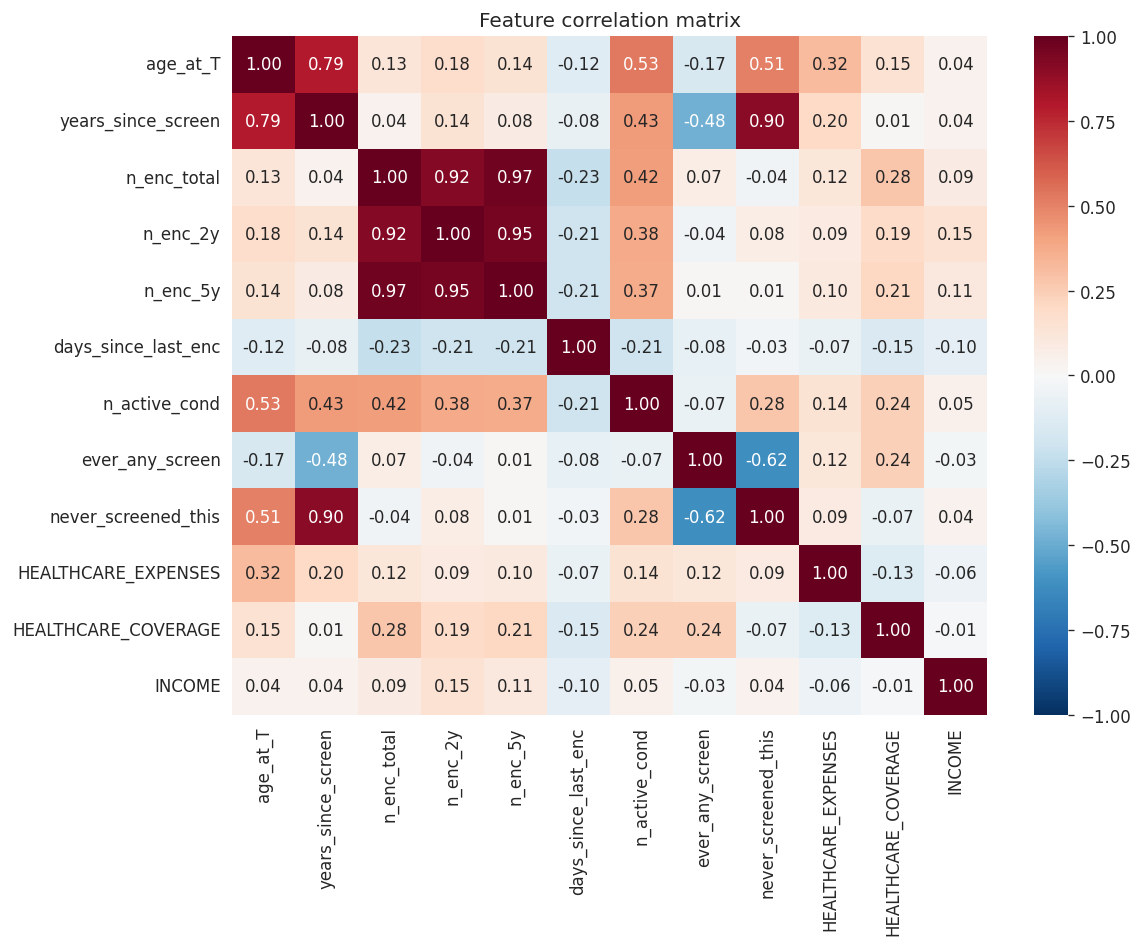

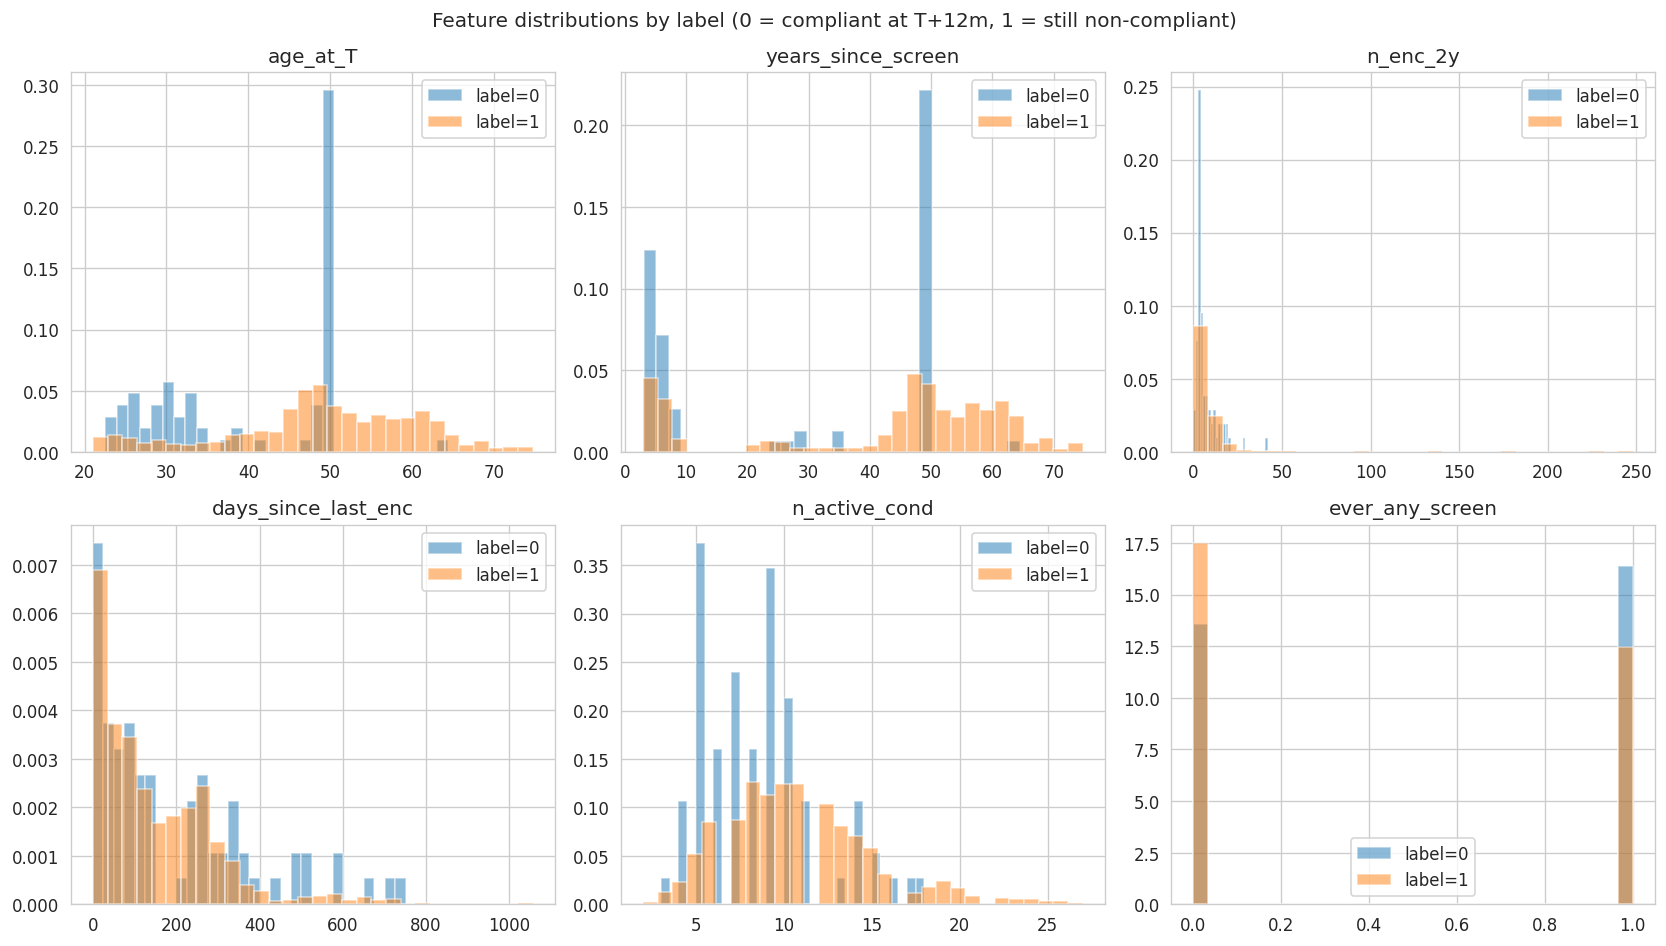

In [11]:
# ============================================================
# Feature sanity checks
# ============================================================

# 1. No NaNs in the modeling frame
print("NaNs per column:")
print(df.isna().sum()[df.isna().sum() > 0])

# 2. Correlation between features (flag high multicollinearity)
numeric_feats = ['age_at_T', 'years_since_screen', 'n_enc_total',
                 'n_enc_2y', 'n_enc_5y', 'days_since_last_enc',
                 'n_active_cond', 'ever_any_screen', 'never_screened_this']
sdoh_present = [c for c in ['HEALTHCARE_EXPENSES','HEALTHCARE_COVERAGE','INCOME']
                if c in df.columns]
numeric_feats += sdoh_present

corr = df[numeric_feats].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

# 3. Feature distributions by label (is there visible signal?)
# For each numeric feature, compare compliant (label=0) vs non-compliant (label=1)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features_to_plot = ['age_at_T', 'years_since_screen', 'n_enc_2y',
                    'days_since_last_enc', 'n_active_cond', 'ever_any_screen']
for ax, f in zip(axes.flat, features_to_plot):
    for lbl, grp in df.groupby('label'):
        ax.hist(grp[f], bins=30, alpha=0.5, label=f'label={lbl}', density=True)
    ax.set_title(f)
    ax.legend()
plt.suptitle('Feature distributions by label (0 = compliant at T+12m, 1 = still non-compliant)')
plt.tight_layout()
plt.show()

#### Discussion

For **years_since_screen** (top middle panel), the two groups separate in a very clean way. The blue distribution (label 0 — compliant by T+12 months) piles up at the **low** end: these are mostly patients who were only a little overdue. The orange distribution (label 1 — still non-compliant) piles up at the **high** end: patients who are many years overdue or effectively never screened for this test. That lines up with the idea that time since the last screen is one of the strongest single features in the dataset. For **n_enc_2y** (top right), separation is also strong. Compliant patients (blue) have a tall spike at low values but a long tail to the right, so “got back on track” includes both light and heavy utilizers. Non-compliant patients (orange) sit **crushed near zero** — people who stay overdue rarely have recent visits — which is easy to explain in clinical terms. The **heatmap** supports the same overall story. Even with imperfect imputation, you can still see how Synthea ties things together: **age and comorbidity** rise together (about 0.53), as you would expect for older, sicker patients; **encounter counts and comorbidity** are moderately linked (about 0.37–0.42), because sicker people see providers more; and the **SDOH-style fields** line up with **care use** (for example, healthcare expenses and coverage with encounter counts). That matches the earlier warning that in Synthea, “healthcare expenses” is largely built from encounter costs, so it is **partly redundant** with how often someone visits rather than a fully separate social-risk signal.

### Modeling

In [12]:
# ============================================================
# 2.2 Modeling: GroupKFold (split by patient) + 2 classifiers
# ============================================================
# Splitting: GroupKFold on PATIENT, 5 folds. A patient contributes up
# to 2 rows (colorectal + cervical for women aged 45-65; only one of
# the two otherwise). Breast was dropped upstream due to degenerate
# labels. Row-splitting would leak shared demographics and utilization
# features across folds; group-splitting prevents it.
#
# Two models on purpose -> pair a linear model with a tree ensemble (For tabular data)
#   - LogisticRegression (L2, class_weight='balanced'): interpretable
#     baseline; coefficients give direction + relative magnitude.
#   - HistGradientBoostingClassifier: picks up nonlinear interactions
#     (e.g. low-utilization AND never-screened) and handles NaNs.
#
# Metrics we actually care about:
#   - ROC-AUC: how well we rank.
#   - Average Precision (PR-AUC): honest under imbalance.
#   - Brier: calibration quality (matters if risk scores drive
#     outreach budget allocation).
#   - Lift@K: the clinically actionable statistic -- if we only have
#     budget to call 10-20% of overdue patients, how much better is
#     our targeting than random?
# ------------------------------------------------------------------------

from sklearn.model_selection import GroupKFold
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.impute          import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import HistGradientBoostingClassifier
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                     brier_score_loss, roc_curve,
                                     precision_recall_curve)

# Categorical features
CAT_COLS = ['screening','GENDER','RACE','ETHNICITY']
# Numerical features
NUM_COLS = ['age_at_T','years_since_screen','never_screened_this',
            'n_enc_total','n_enc_2y','n_enc_5y','days_since_last_enc',
            'n_active_cond','ever_any_screen'] + sdoh_cols

X_df   = df[CAT_COLS + NUM_COLS].copy()
y      = df['label'].values
groups = df['Id'].values # Splits are by patient

# Preprocessing for Logistic Regression
pre_lr = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS), # categorical features to be one-hot encoded
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), NUM_COLS), # numerical features to be standardized
])
# Preprocessing for HistGradientBoostingClassifier
pre_hgb = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
    ('num', 'passthrough', NUM_COLS), # numerical features to be passed through because it can use default missing value handling, and tree splits don't need linear scaling
])

models = {
    'LogReg': Pipeline([('pre', pre_lr),
                        ('clf', LogisticRegression(max_iter=1000,
                                                   class_weight='balanced'))]), # handle imbalance by using importance in the loss instead of row counts
    'HGB':    Pipeline([('pre', pre_hgb),
                        ('clf', HistGradientBoostingClassifier(
                            max_iter=300, learning_rate=0.05, max_depth=6,
                            random_state=42))]),
}

gkf = GroupKFold(n_splits=5) # enforce all rows for a patient in the same fold
oof = {k: np.zeros(len(df)) for k in models} # out-of-fold predictions
cv_rows = []
for name, pipe in models.items():
    for fold, (tr, te) in enumerate(gkf.split(X_df, y, groups)):
        pipe.fit(X_df.iloc[tr], y[tr])
        p = pipe.predict_proba(X_df.iloc[te])[:, 1]
        oof[name][te] = p
        cv_rows.append({
            'model': name, 'fold': fold,
            'auc':   roc_auc_score(y[te], p),
            'ap':    average_precision_score(y[te], p),
            'brier': brier_score_loss(y[te], p),
        })

cv = pd.DataFrame(cv_rows)
print("5-fold GroupKFold (split by PATIENT):")
print(cv.groupby('model')[['auc','ap','brier']].agg(['mean','std']).round(3))


5-fold GroupKFold (split by PATIENT):
          auc            ap         brier       
         mean    std   mean    std   mean    std
model                                           
HGB     0.896  0.016  0.989  0.004  0.054  0.014
LogReg  0.760  0.040  0.977  0.005  0.194  0.009


In [13]:
# Paired comparison — is HGB meaningfully better than LR per fold? (alghouth we can't really do statistical testing because we only have 5 folds)
lr_folds  = cv[cv['model'] == 'LogReg'].sort_values('fold').reset_index(drop=True)
hgb_folds = cv[cv['model'] == 'HGB'].sort_values('fold').reset_index(drop=True)
diff = pd.DataFrame({
    'fold':      lr_folds['fold'],
    'auc_diff':  hgb_folds['auc']  - lr_folds['auc'],
    'ap_diff':   hgb_folds['ap']   - lr_folds['ap'],
    'brier_diff': hgb_folds['brier'] - lr_folds['brier'],
})
print("\nPer-fold differences (HGB - LogReg):")
print(diff.round(3))
print(f"\nHGB wins AUC in {(diff['auc_diff'] > 0).sum()}/5 folds")


Per-fold differences (HGB - LogReg):
   fold  auc_diff  ap_diff  brier_diff
0     0     0.123    0.007      -0.131
1     1     0.173    0.012      -0.175
2     2     0.157    0.015      -0.140
3     3     0.159    0.020      -0.126
4     4     0.071    0.007      -0.127

HGB wins AUC in 5/5 folds


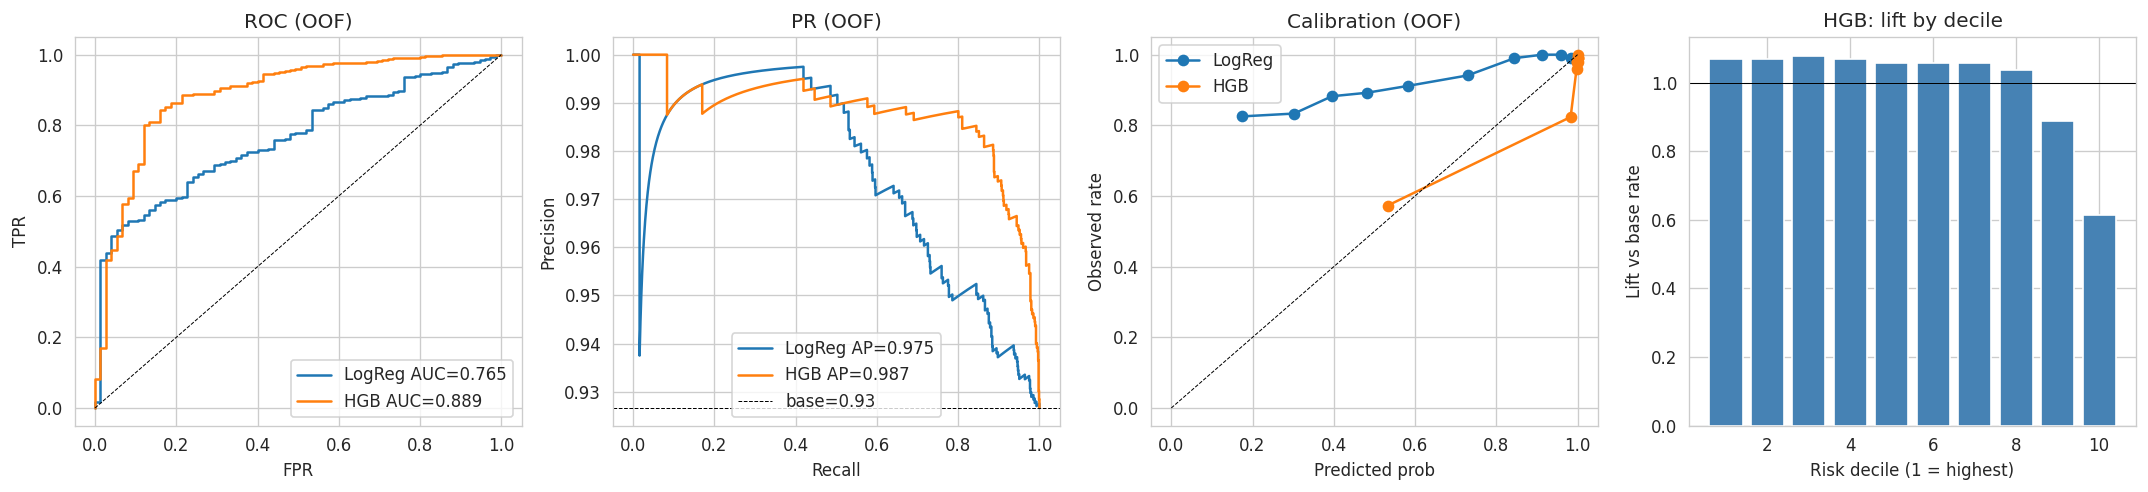


Outreach-targeting metrics (OOF):
  LogReg  lift@10%=1.07   lift@20%=1.07   capture@20%=21.4%
  HGB     lift@10%=1.07   lift@20%=1.07   capture@20%=21.3%


In [14]:
# ============================================================
# 2.2 Evaluation: ROC / PR / calibration / lift-by-decile
# ============================================================
# Four panels side-by-side for a complete picture:
#   1) ROC     -- ranking quality
#   2) PR      -- honest view given imbalance (shows base rate line)
#   3) Calib   -- are predicted probabilities trustworthy as probabilities?
#   4) Lift    -- decile-wise enrichment vs base rate; this is the
#                 shape that matters for outreach prioritization.
# All four use OUT-OF-FOLD predictions from the GroupKFold loop above,
# so no leakage.
# ------------------------------------------------------------------------

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
base = y.mean()

# ROC
for name, p in oof.items():
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y, p):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.6)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC (OOF)')
axes[0].legend()

# PR
for name, p in oof.items():
    pr, rc, _ = precision_recall_curve(y, p)
    axes[1].plot(rc, pr, label=f'{name} AP={average_precision_score(y, p):.3f}')
axes[1].axhline(base, color='k', ls='--', lw=0.6, label=f'base={base:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR (OOF)')
axes[1].legend()

# Calibration
for name, p in oof.items():
    pt, pp = calibration_curve(y, p, n_bins=10, strategy='quantile')
    axes[2].plot(pp, pt, 'o-', label=name)
axes[2].plot([0, 1], [0, 1], 'k--', lw=0.6)
axes[2].set(xlabel='Predicted prob', ylabel='Observed rate',
            title='Calibration (OOF)')
axes[2].legend()

# Lift by decile (use the stronger model = HGB)
scores  = oof['HGB']
order   = np.argsort(-scores)
deciles = np.array_split(order, 10)
lift    = [y[d].mean() / base for d in deciles]
axes[3].bar(range(1, 11), lift, color='steelblue')
axes[3].axhline(1.0, color='k', lw=0.6)
axes[3].set(xlabel='Risk decile (1 = highest)',
            ylabel='Lift vs base rate', title='HGB: lift by decile')

plt.tight_layout(); plt.show()

# Outreach-targeting summary stats
def lift_at(p, k):
    n   = int(len(y) * k)
    idx = np.argsort(-p)[:n]
    return y[idx].mean() / base

def capture_at(p, k):
    n   = int(len(y) * k)
    idx = np.argsort(-p)[:n]
    return y[idx].sum() / y.sum()

print("\nOutreach-targeting metrics (OOF):")
for name, p in oof.items():
    print(f"  {name:6s}  lift@10%={lift_at(p,0.10):.2f}   "
          f"lift@20%={lift_at(p,0.20):.2f}   "
          f"capture@20%={capture_at(p,0.20):.1%}")


### Feature importance

['screening_cervical', 'screening_colorectal', 'GENDER_F', 'GENDER_M', 'RACE_asian', 'RACE_black', 'RACE_hawaiian', 'RACE_native', 'RACE_other', 'RACE_white', 'ETHNICITY_hispanic', 'ETHNICITY_nonhispanic', 'age_at_T', 'years_since_screen', 'never_screened_this', 'n_enc_total', 'n_enc_2y', 'n_enc_5y', 'days_since_last_enc', 'n_active_cond', 'ever_any_screen', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']
[ 1.3850031  -1.35268781  0.13960907 -0.10729378 -0.43999829 -0.09163697
 -0.79408706  0.75723882  0.90764977 -0.30685097 -0.09854268  0.13085797
  1.25676309  0.27045942  0.33513861  0.32931252 -0.73913001  0.38444872
 -0.04682837  0.23039248 -0.15181836 -0.01865861 -0.14859311  0.07793458]


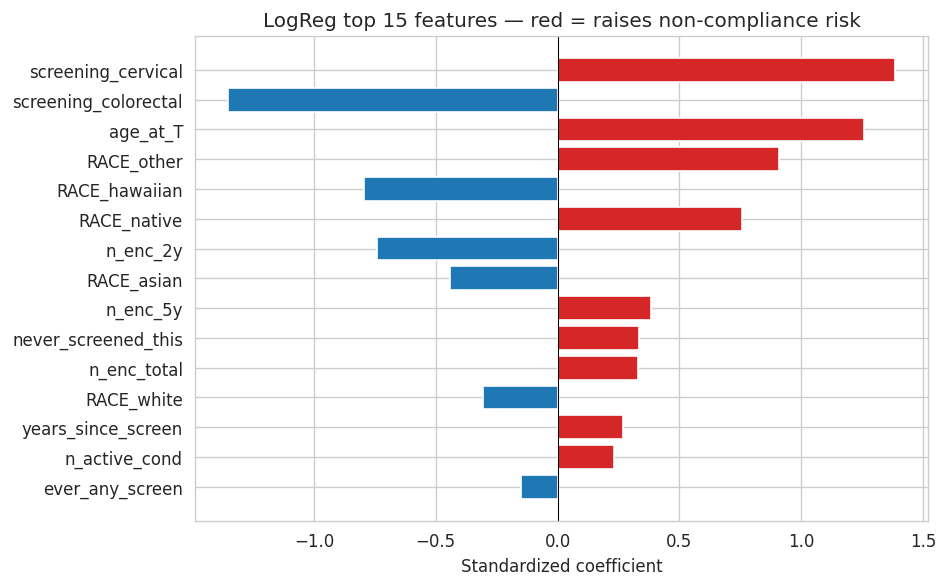

             feature   coef
  screening_cervical  1.385
screening_colorectal -1.353
            age_at_T  1.257
          RACE_other  0.908
       RACE_hawaiian -0.794
         RACE_native  0.757
            n_enc_2y -0.739
          RACE_asian -0.440
            n_enc_5y  0.384
 never_screened_this  0.335
         n_enc_total  0.329
          RACE_white -0.307
  years_since_screen  0.270
       n_active_cond  0.230
     ever_any_screen -0.152


In [15]:
# ============================================================
# 2.2 Feature importance (LogReg coefficients, full-fit)
# ============================================================

# in our case, fitting all data on LogReg is fine for interpretation because (a) we already
# evaluated on OOF predictions above, and (b) coefficient direction
# is stable across folds. Positive coef => increases probability of
# REMAINING non-compliant (prediction toward class 1); negative => decreases it (toward 0).
#
# This is also a gut-check for leakage: if a single feature dominates
# with an extremely high coefficient, we suspect a leak. Here the expected winners
# are `years_since_screen`, `never_screened_this`, and low-utilization
# signals -- all observable strictly before T.
# ------------------------------------------------------------------------

pipe_lr = models['LogReg'].fit(X_df, y) # fit the model on every row since we want to see the importance of each feature
oh      = pipe_lr.named_steps['pre'].named_transformers_['cat'] # fitted one-hot encoder -> to retrieve feature names below
names   = list(oh.get_feature_names_out(CAT_COLS)) + NUM_COLS # names of the features
coef    = pipe_lr.named_steps['clf'].coef_[0] # coefficients of the model

print(names)
print(coef)

imp = (pd.DataFrame({'feature': names, 'coef': coef}) # construct a dataframe of the features and their coefficients
         .assign(absc=lambda d: d['coef'].abs()) # absolute value of the coefficients
         .sort_values('absc', ascending=False) # sort by the absolute value of the coefficients
         .head(15)) # get the top 15 features

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tab:red' if c > 0 else 'tab:blue' for c in imp['coef']]
ax.barh(imp['feature'][::-1], imp['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='k', lw=0.6)
ax.set_title('LogReg top 15 features — red = raises non-compliance risk')
ax.set_xlabel('Standardized coefficient')
plt.tight_layout(); plt.show()

print(imp[['feature', 'coef']].round(3).to_string(index=False))


### 2.2 Discussion

This task was to predict which USPSTF-eligible patients who were already non-compliant with screening at `T = 2025-01-01` would still be non-compliant 12 months later. The unit of analysis was a (patient, screening) pair, so one patient could contribute more than one row. To avoid leakage, all features were built only from data before T, and validation used GroupKFold by `PATIENT`, so the same patient never appeared in both train and validation within a fold.

**What actually happened.** The raw eligible-and-non-compliant cohort was **1,536 rows across 926 unique patients**, with this label distribution:

| screening  | rows | P(remains non-compliant) |
|------------|------|--------------------------|
| breast     | 514  | **1.000** |
| cervical   | 621  | 0.934 |
| colorectal | 401  | 0.915 |

Breast has a **degenerate label** (single class) — Synthea's breast-cancer module generated 32 mammograms in the label window, but zero of them went to a patient who was non-compliant at T (overlap = 0 as shown in the cells above), so the women in the breast cohort are uniformly label-1 by construction. Training on this would learn nothing and would inflate headline metrics. I dropped breast before modeling, leaving **1,022 rows / 856 patients**, base rate ≈ 0.925. Cervical and colorectal both show real variation, so the remaining task is learnable in principle — just heavily imbalanced.

**Headline metrics (5-fold GroupKFold by patient, OOF).**

| model  | AUC (mean ± sd) | AP (mean ± sd) | Brier (mean ± sd) |
|--------|-----------------|----------------|-------------------|
| LogReg | 0.760 ± 0.040   | 0.977 ± 0.005  | 0.194 ± 0.009     |
| HGB    | 0.896 ± 0.016   | 0.989 ± 0.004  | 0.054 ± 0.014     |

HGB beats LogReg on AUC in **5 / 5 folds** (per-fold ΔAUC 0.07–0.17) and is materially better calibrated (Brier 0.054 vs 0.194). LogReg is underfitting the non-linear interaction between `years_since_screen`, `age_at_T`, and the screening type, which HGB's tree splits capture naturally. So on *ranking* quality, HGB is the right pick.

**But the operational metric tells a different story.** The truth-teller for an outreach-targeting use case is lift at the top decile, not AUC:

```
LogReg  lift@10% = 1.07   lift@20% = 1.07   capture@20% = 21.4%
HGB     lift@10% = 1.07   lift@20% = 1.07   capture@20% = 21.3%

```
This means if we target the top 10% highest-risk patients, we only get about 7% more true non-compliant patients than random selection. This is a weak improvement, and HGB has no better advantage there.

Ranking by model score catches only ~21% of eventual non-compliers in the top 20% of rows — *essentially what you would get by random selection* (as it's almost proportional to the size of the outreach pool itself), and the two models are indistinguishable on this metric despite their AUC gap. The reason is the 92.5% base rate: when almost everyone is positive (aka patient remains non-compliant with screening), even if a model is good, that top group cannot improve much over 92.5% because it is already near the ceiling. AUC rewards correctly ranking the rare negatives at the bottom; the business use case (whom to call first with a limited outreach budget) rewards concentrating positives at the top (we care whether the top is enriched with patients who will remain non-complaint), and there is very little room to do that when the positive rate is already 92.5%.

**What the model is actually learning.** Top LogReg coefficients (positive → more likely to remain non-compliant):

| feature              | coef   |
|----------------------|--------|
| screening_cervical   | +1.39  |
| screening_colorectal | −1.35  |
| age_at_T             | +1.26  |
| n_enc_2y             | −0.74  |
| n_enc_5y             | +0.38  |
| never_screened_this  | +0.34  |
| years_since_screen   | +0.27  |

The logistic regression coefficients were still useful as a sanity check. Cervical screening was associated with higher probability of remaining non-compliant than colorectal screening, which matched the raw base rates. Older age, longer time since screening, and never having had that screening also moved in the expected direction. Recent encounters were protective, suggesting that patients seen more recently were more likely to re-enter screening. Some race and ethnicity coefficients appeared large, but these should not be interpreted clinically because the groups were small and likely reflect Synthea simulation artifacts rather than real demographic effects.

**Why the labels came out this way (and what it says about Synthea).** This is the failure mode flagged in 2.1: Synthea's screening modules are largely deterministic conditional on the simulated agent's encounter pattern. A patient who is overdue on 2025-01-01 is one whose module failed to fire a screening event in the prior window; the same failure mode tends to persist — completely so for breast, and to a ~93% extent for cervical and colorectal. The little variation that does exist comes from patients whose module does fire a re-screen in the 12-month window, and those tend to be patients with recent encounters (hence `n_enc_2y` being the most informative utilization feature). Colorectal having slightly more label variation than cervical in this dataset. One possible explanation is that Synthea's colorectal screening timing placed more patients near the compliance boundary (10 years), so some could switch status during follow-up. This is a *data-generation* observation, not a clinical finding.

**Improvement in hindsight.** With hindsight, I would reframe the prediction task. The clinically meaningful question is persistent non-compliance, but this Synthea dataset does not support it well because the label is too imbalanced. A better Synthea-compatible task may be to predict current compliance status among all eligible patients at T, or to use multiple sliding index dates so the dataset captures more transitions between compliant and non-compliant states. I would also keep the breast-screening degeneracy as part of the report because it is an important finding about the simulator.

**What transfers to real EHR (and what does not).** The pipeline itself is still valid and transferable. USPSTF rule encoding, strict pre-index feature construction, patient-grouped validation, and lift@K evaluation are all appropriate for a real EHR outreach problem. What does not transfer is the numeric performance from Synthea. In real EHR data, screening non-compliance would likely be less extreme and more influenced by access, utilization, socioeconomic factors, and care patterns that Synthea does not fully represent.

In summary, HGB was the better model by AUC and calibration, but neither model produced useful top-decile lift for outreach. The main conclusion is therefore not that the model is ready for deployment, but that the modeling pipeline is sound while this particular Synthea label is too imbalanced and deterministic to support meaningful outreach prioritization.

---
---
# Problem 3: Influenza-Like Illness (ILI) Forecasting

## Background
The CDC's ILINet surveillance system collects weekly reports of influenza-like illness (ILI) from outpatient healthcare providers across the US, organized by HHS Region. Accurate forecasting of ILI rates 1–4 weeks ahead is a critical public health capability that informs hospital staffing, antiviral stockpiling, and public messaging.

This is a **time series forecasting** problem with strong seasonality, making it fundamentally different from the cross-sectional classification in Problems 1 and 2.

## Dataset
CDC FluView ILINet data, available via the CMU Delphi Epidata API or direct CDC download. Weekly %ILI (weighted) by HHS region, spanning 20+ seasons.

## Learning Objectives
- Implement proper **temporal train/test splits** (no random splitting!)
- Build and compare time-series baselines vs. ML approaches
- Evaluate at multiple forecast horizons
- Understand the challenges of epidemic peak prediction

---


## 3.1 Dataset Loading

In [16]:
# ============================================================
# 3.1 LOAD CDC ILINET DATA
# ============================================================

# Download ILI data from the CMU Delphi Epidata API (reliable, no auth needed)
import requests

ili_raw = None

try:
    url = "https://api.delphi.cmu.edu/epidata/fluview"
    params = {
        "regions": "nat",
        "epiweeks": "201001-202352"
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    if data["result"] != 1:
        raise ValueError(f"API returned result={data['result']}")

    ili_raw = pd.DataFrame(data["epidata"])

    # Standardize columns
    rename_map = {}
    if 'wili' in ili_raw.columns:
        rename_map['wili'] = 'weighted_ili'
    elif 'ili' in ili_raw.columns and 'weighted_ili' not in ili_raw.columns:
        rename_map['ili'] = 'weighted_ili'
    ili_raw = ili_raw.rename(columns=rename_map)

    # Derive year/week from epiweek
    if 'epiweek' in ili_raw.columns:
        ili_raw['epiweek'] = ili_raw['epiweek'].astype(int)
        ili_raw['year'] = ili_raw['epiweek'] // 100
        ili_raw['week'] = ili_raw['epiweek'] % 100

    # Derive week_start date
    if 'year' in ili_raw.columns and 'week' in ili_raw.columns:
        ili_raw['week_start'] = pd.to_datetime(
            ili_raw['year'].astype(str) + '-W' +
            ili_raw['week'].astype(str).str.zfill(2) + '-1',
            format='%G-W%V-%u', errors='coerce'
        )

    print(f"✅ Loaded ILI data from Delphi Epidata API")

except Exception as e:
    print(f"⚠️ Delphi API failed: {e}")

print(f"\nDataset shape: {ili_raw.shape}")
print(f"Columns: {list(ili_raw.columns)}")
print(f"Year range: {ili_raw['year'].min()} to {ili_raw['year'].max()}")
print(f"Regions: {ili_raw['region'].nunique()}")
print(ili_raw.head())


✅ Loaded ILI data from Delphi Epidata API

Dataset shape: (730, 19)
Columns: ['release_date', 'region', 'issue', 'epiweek', 'lag', 'num_ili', 'num_patients', 'num_providers', 'num_age_0', 'num_age_1', 'num_age_2', 'num_age_3', 'num_age_4', 'num_age_5', 'weighted_ili', 'ili', 'year', 'week', 'week_start']
Year range: 2010 to 2023
Regions: 1
  release_date region   issue  epiweek  lag  num_ili  num_patients  \
0   2013-12-31    nat  201352   201001  207    14299        721138   
1   2013-12-31    nat  201352   201002  206    14088        770895   
2   2013-12-31    nat  201352   201003  205    14757        766177   
3   2013-12-31    nat  201352   201004  204    15122        785580   
4   2013-12-31    nat  201352   201005  203    16037        767773   

   num_providers  num_age_0  num_age_1 num_age_2  num_age_3  num_age_4  \
0           1996       4998       3961      None       3333       1244   
1           2016       4877       4614      None       2793       1182   
2           205

In [17]:
# ============================================================
# 3.1b PICK A SINGLE REGION FOR FOCUSED ANALYSIS
# ============================================================
# We'll focus on one region

TARGET_REGION = ili_raw['region'].unique()[0]  # First region
print(f"Focusing on: {TARGET_REGION}")

ili = ili_raw[ili_raw['region'] == TARGET_REGION].copy()

# Create a proper date index
if 'week_start' in ili.columns:
    ili = ili.sort_values('week_start').reset_index(drop=True)
    ili['date'] = ili['week_start']
else:
    # Construct date from year + week
    ili['date'] = pd.to_datetime(ili['year'].astype(str) + '-W' +
                                  ili['week'].astype(str).str.zfill(2) + '-1',
                                  format='%Y-W%W-%w', errors='coerce')
    ili = ili.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

print(f"Records for {TARGET_REGION}: {len(ili)}")
print(f"Date range: {ili['date'].min()} to {ili['date'].max()}")
print(f"\n%ILI summary stats:")
print(ili['weighted_ili'].describe())


Focusing on: nat
Records for nat: 730
Date range: 2010-01-04 00:00:00 to 2023-12-25 00:00:00

%ILI summary stats:
count    730.000000
mean       2.017086
std        1.353939
min        0.529813
25%        1.108860
50%        1.556255
75%        2.370798
max        7.521330
Name: weighted_ili, dtype: float64


### Memo: Making sense of the data
Each row is one epidemiological week of U.S. national influenza-like illness (ILI) surveillance table and then added a few convenience columns.
- only the national region
- all epiweeks from 2010 week 01 to 2023 week 52
- `epiweek` = 201001 means the illness data is for 2010 week 1
- `year` extracted from epiweek, `week` extracted from epiweek

Surveillance count columns
- `num_ili`: number of visits classified as influenza-like illness
- `num_patients`: total patient visits observed
- `num_providers`: number of reporting providers

Age-group columns
- `num_age_n`: ILI counts split into CDC/FluView age buckets. Notice that `num_age_2` is None. The field is missing?

ili vs. weighted_ili
- $\text{ili} \approx \frac{\text{num\_ili}}{\text{num\_patients}} \times 100$
- weighted_ili: population-weighted ILI percentage version.


In [18]:
ili_raw['num_age_2'].isna().sum() # num_age_2 is an empty column

np.int64(730)

## 3.2 Problem statement (50 pts)

Build a forecasting model that predicts ILI rates 1, 2, 3, and 4 weeks ahead.

Time series data requires fundamentally different treatment than cross-sectional data: your data splitting, feature engineering, baseline selection, and evaluation must all reflect this. A strong submission will establish baselines that are genuinely hard to beat (not just strawmen), honestly assess where ML adds value over simpler strategies, and characterize when forecasts fail, not just how much error they have on average. Consider how your approach compares to the state of the art (the CDC runs a public forecasting challenge FluSight), what exogenous data sources could improve predictions beyond lagged ILI values, and whether a single temporal split gives you enough confidence in your performance estimates.

We expect executable code, figures, and written explanations.

### 3.2.1 Setup

In [19]:
# ============================================================
# 3.2 Setup: clean series, temporal holdout, feature engineering
# ============================================================
# At week t, create features using only information available up to the past (before week t)
# then train models to predict future values y_{t+1}, ..., y_{t+4}
#
# Splitting rules (all forecasting-specific):
#   - NO random shuffling. A random split would let the model "see
#     the future" via nearby weeks in train, collapsing test error.
#   - Hold out the most recent ~3 flu seasons (2020-07 onwards) as a
#     FINAL TEST block. Everything before is available for model
#     selection. Walk-forward CV (trains on earlier data and validates on later data) adds more splits.
#   - The COVID era (2020-03 to 2021-06) is a documented structural
#     break in ILI: school closures and masking flattened the 2020-21
#     season almost to zero. We keep it in the holdout on purpose so
#     we can see which methods are fragile vs. robust.
#
# Feature engineering (only information available AT time t):
#   - Short lags: y_{t-1} ... y_{t-4}.
#   - Longer lags at 8, 13, 26, 52 weeks (seasonal echo at 52).
#   - Rolling stats: 4-wk and 12-wk mean/std ending at t-1. => using moving average
#   - Seasonal encoding: sin/cos of week-of-year (period 52). => sin/cos tell the model the season of the year in a smooth circular way
#   - Momentum: diffs at 1 and 4 weeks. (measure whether flu activity is going up or down)
# ------------------------------------------------------------------------

# Past                                             Future
# y_{t-52} ... y_{t-4} y_{t-3} y_{t-2} y_{t-1} | y_t | y_{t+1} y_{t+2} y_{t+3} y_{t+4}
#        ↑          ↑        ↑      ↑      ↑            ↑       ↑       ↑       ↑
#     lag_52     lag_4    lag_3  lag_2  lag_1        targets to predict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ts = (ili[['date', 'weighted_ili']]
        .dropna(subset=['weighted_ili'])
        .drop_duplicates(subset='date', keep='last')  # ISO week edge case can produce dup week_start
        .sort_values('date')
        .reset_index(drop=True)
        .set_index('date'))
ts.index = pd.DatetimeIndex(ts.index)
y_all = ts['weighted_ili'].astype(float) # predict weighted %ILI

print(f"Series length: {len(y_all)} weeks")
print(f"Date range   : {y_all.index.min().date()} -> {y_all.index.max().date()}")
print(f"%ILI mean/min/max: {y_all.mean():.2f} / {y_all.min():.2f} / {y_all.max():.2f}")

# -------- temporal split -------- => NO RANDOM SHUFFLING
SPLIT_DATE = pd.Timestamp('2020-07-01')  # everything from 2020-07-01 onward becomes the final test period.
train_mask = y_all.index <  SPLIT_DATE
test_mask  = y_all.index >= SPLIT_DATE
print(f"\nTrain weeks: {train_mask.sum()}  ({y_all.index[train_mask].min().date()} -> {y_all.index[train_mask].max().date()})")
print(f"Test  weeks: {test_mask.sum()}   ({y_all.index[test_mask].min().date()} -> {y_all.index[test_mask].max().date()})")

# -------- feature matrix --------
def build_features(series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=series.index)
    for lag in [1, 2, 3, 4, 8, 13, 26, 52]:
        df[f'lag_{lag}'] = series.shift(lag)
    past = series.shift(1)  # strictly past -> no leak of y_t
    df['roll4_mean']  = past.rolling(4).mean()
    df['roll4_std']   = past.rolling(4).std()
    df['roll12_mean'] = past.rolling(12).mean()
    df['roll12_std']  = past.rolling(12).std()
    df['diff_1'] = past.diff(1)
    df['diff_4'] = past.diff(4)
    woy = series.index.isocalendar().week.astype(int).to_numpy()
    df['sin_woy'] = np.sin(2 * np.pi * woy / 52)
    df['cos_woy'] = np.cos(2 * np.pi * woy / 52)
    return df

feat = build_features(y_all)
HORIZONS = [1, 2, 3, 4]
for h in HORIZONS:
    feat[f'target_h{h}'] = y_all.shift(-h).values

FEATURE_COLS = [c for c in feat.columns if not c.startswith('target_')]
print(f"\n#features = {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Series length: 729 weeks
Date range   : 2010-01-04 -> 2023-12-25
%ILI mean/min/max: 2.01 / 0.53 / 7.52

Train weeks: 547  (2010-01-04 -> 2020-06-29)
Test  weeks: 182   (2020-07-06 -> 2023-12-25)

#features = 16
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'lag_13', 'lag_26', 'lag_52', 'roll4_mean', 'roll4_std', 'roll12_mean', 'roll12_std', 'diff_1', 'diff_4', 'sin_woy', 'cos_woy']


### 3.2.2 Create Baselines

In [20]:
# ============================================================
# 3.2 Baselines (no learning -> these are the bar to beat)
# ============================================================
# Three domain-standard baselines. If our ML model cannot beat all
# three on held-out data, we don't actually have a forecasting model
#
#   1. PERSISTENCE (a.k.a. naive-1): y_hat_{t+h} = y_t.
#      Prediction: Next week will look like this week.
#   2. SEASONAL NAIVE: y_hat_{t+h} = y_{t+h-52}.
#      Prediction: This week behaves like last year's same week.
#   3. CLIMATOLOGY: y_hat_{t+h} = mean of y at ISO-week(t+h) across
#      all TRAIN years. A strong, smoothed seasonal baseline --
#      the CDC FluSight challenge publishes this as its reference.
#      Prediction: This week usually has this average flu level.
# ------------------------------------------------------------------------

# Compute baseline predictions aligned to forecast target dates.
def persistence_pred(series, test_idx, h):
    # forecast for date test_idx[i] is y at (test_idx[i] - h weeks)
    src_dates = test_idx - pd.Timedelta(weeks=h)
    return series.reindex(src_dates).values

def seasonal_naive_pred(series, test_idx, h):
    src_dates = test_idx - pd.Timedelta(weeks=52)
    return series.reindex(src_dates).values

def climatology_pred(series_train, test_idx):
    # mean by ISO week number, computed ONLY from training data
    train_df = pd.DataFrame({'y': series_train.values,
                             'woy': series_train.index.isocalendar().week.astype(int).values})
    woy_mean = train_df.groupby('woy')['y'].mean()
    test_woy = test_idx.isocalendar().week.astype(int).values
    return woy_mean.reindex(test_woy).values

# Evaluation dates = test dates that have a valid target (drop last h rows)
def eval_idx(y_series, h):
    return y_series.index[(y_series.index >= SPLIT_DATE) &
                          (y_series.index <= y_series.index.max() - pd.Timedelta(weeks=h))]

baseline_preds = {h: {} for h in HORIZONS}
baseline_true  = {}
for h in HORIZONS:
    idx_h = eval_idx(y_all, h)
    baseline_true[h] = y_all.reindex(idx_h + pd.Timedelta(weeks=h)).values
    baseline_preds[h]['persistence']    = persistence_pred(y_all, idx_h, 0)  # y_t itself
    baseline_preds[h]['seasonal_naive'] = seasonal_naive_pred(y_all, idx_h + pd.Timedelta(weeks=h), 52)
    baseline_preds[h]['climatology']    = climatology_pred(y_all[train_mask], idx_h + pd.Timedelta(weeks=h))

# Sanity print
for name in ['persistence', 'seasonal_naive', 'climatology']:
    p = baseline_preds[1][name]
    print(f"{name:16s} h=1  n={len(p):4d}  nan={np.isnan(p).sum()}  mean={np.nanmean(p):.2f}")


persistence      h=1  n= 181  nan=0  mean=2.16
seasonal_naive   h=1  n= 181  nan=0  mean=2.30
climatology      h=1  n= 181  nan=1  mean=1.89


### 3.2.3 Create ML models

In [21]:
# ============================================================
# 3.2 ML models: direct multi-horizon forecasting
# ============================================================
# create one separate model per horizon h (h = 1 to 4 weeks ahead), each trained to
# predict y_{t+h} from features at t. Safer than recursive/iterated
# forecasting (like predict week 1 then use that to predict week 2, then 3, then 4) 
# because errors don't compound through the chain.
#
# Two models, on purpose -- pair a linear model with a tree ensemble:
#   - Ridge (alpha fixed at 1.0):
#     linear in lags -> basically a regularized AR + seasonal
#     regression. Interpretable, fast, a strong baseline in its own
#     right for stationary-ish series.
#   - HistGradientBoostingRegressor (tree-based ensemble): picks up nonlinearity (e.g.
#     if flue is high and rising fast in winter, the next few weeks may behave differently than
#     if flu is low and rising slwoly in summer.) and interactions between
#     lag and week-of-year (e.g. lag_1 = 2.5 may mean differnt thing in Jan vs July). 
#     Handles NaN natively, which matters because the long lags leave NaN rows early in the series.
#
# Total = 8 models
# Ridge model for h=1
# Ridge model for h=2
# Ridge model for h=3
# Ridge model for h=4
#
# HGB model for h=1
# HGB model for h=2
# HGB model for h=3
# HGB model for h=4
# ------------------------------------------------------------------------

from sklearn.linear_model import Ridge
from sklearn.ensemble     import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.impute        import SimpleImputer

def train_eval_direct(feat_df, train_mask, test_mask, horizons):
    """Return dict[h] -> {'ridge':pred, 'hgb':pred, 'y_true':arr, 'dates':idx}"""
    out = {}
    for h in horizons:
        tgt = f'target_h{h}'
        # rows where features AND target are finite (training)
        tr_rows = feat_df.index[train_mask].intersection(
            feat_df.dropna(subset=FEATURE_COLS + [tgt]).index)
        # test rows: target must exist; features can have NaN (HGB) or imputed (Ridge)
        te_rows = feat_df.index[test_mask].intersection(
            feat_df.dropna(subset=[tgt]).index)

        X_tr = feat_df.loc[tr_rows, FEATURE_COLS].values
        y_tr = feat_df.loc[tr_rows, tgt].values
        X_te = feat_df.loc[te_rows, FEATURE_COLS].values
        y_te = feat_df.loc[te_rows, tgt].values

        ridge = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler()),
            ('reg',    Ridge(alpha=1.0, random_state=0)),
        ]).fit(X_tr, y_tr)

        hgb = HistGradientBoostingRegressor(
            max_depth=6, learning_rate=0.05, max_iter=400,
            min_samples_leaf=20, l2_regularization=1.0, random_state=0
        ).fit(X_tr, y_tr)

        out[h] = {
            'ridge':  ridge.predict(X_te),
            'hgb':    hgb.predict(X_te),
            'y_true': y_te,
            'dates':  te_rows,
            'model_ridge': ridge,
            'model_hgb':   hgb,
        }
        print(f"h={h}  n_train={len(tr_rows)}  n_test={len(te_rows)}  "
              f"ridge_test_mae={np.mean(np.abs(out[h]['ridge'] - y_te)):.3f}  "
              f"hgb_test_mae={np.mean(np.abs(out[h]['hgb']   - y_te)):.3f}")
    return out

ml_out = train_eval_direct(feat, train_mask, test_mask, HORIZONS)


h=1  n_train=495  n_test=181  ridge_test_mae=0.388  hgb_test_mae=0.309
h=2  n_train=495  n_test=180  ridge_test_mae=0.573  hgb_test_mae=0.521
h=3  n_train=495  n_test=179  ridge_test_mae=0.705  hgb_test_mae=0.700
h=4  n_train=495  n_test=178  ridge_test_mae=0.814  hgb_test_mae=0.725


It seems like the expected patterns appears: Predicting 1 week ahead is easier than predicting 4 weeks ahead. This means that the farther into the future we predict, the less accurate the model becomes.

### 3.2.4 Evaluation

In [22]:
# ============================================================
# 3.2 Evaluation: MAE / RMSE / MAPE by horizon, all methods
# ============================================================
# Here we compare all five methods: 3 baselines and ML models which include Ridge and HGB using 3 metrics--MAE, RMSE, MAPE.
# Headline metrics for every method at every horizon (h = 1,2,3,4). We also
# include MAE ratio vs. persistence (skill score): values < 1.0
# mean the method beats persistence in absolute error.
# ------------------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error

def scores(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-3))) * 100
    return mae, rmse, mape

rows = []
for h in HORIZONS:
    # align baselines to ml_out dates (same test window)
    dates = ml_out[h]['dates']
    y_te  = ml_out[h]['y_true']
    idx_map = pd.Index(baseline_true_dates := (dates))

    # Baselines were computed on eval_idx -> align by date
    # Rebuild baseline preds on the exact ml test dates:
    src_p = y_all.reindex(dates - pd.Timedelta(weeks=0)).values # persistence uses y_t where t = target_date - h
    # Actually: persistence means y_hat_{t+h} = y_t. target_date = t+h => y_t = y_all[target_date - h]
    persistence = y_all.reindex(dates - pd.Timedelta(weeks=h)).values
    snaive      = y_all.reindex(dates - pd.Timedelta(weeks=52)).values
    clim        = climatology_pred(y_all[train_mask], dates)

    for name, pred in [('persistence',    persistence),
                       ('seasonal_naive', snaive),
                       ('climatology',    clim),
                       ('ridge',          ml_out[h]['ridge']),
                       ('hgb',            ml_out[h]['hgb'])]:
        mae, rmse, mape = scores(y_te, pred)
        rows.append({'horizon': h, 'method': name,
                     'MAE': mae, 'RMSE': rmse, 'MAPE%': mape})

metrics = pd.DataFrame(rows)
# Skill score vs persistence
pers = metrics[metrics['method'] == 'persistence'].set_index('horizon')['MAE']
metrics['MAE_skill_vs_pers'] = metrics.apply(lambda r: r['MAE'] / pers.loc[r['horizon']], axis=1)

pivot = metrics.pivot(index='method', columns='horizon',
                      values=['MAE', 'RMSE', 'MAE_skill_vs_pers'])
print("Test block 2020-07-01 -> end  (covers COVID era + 2022-23 rebound)\n")
print(pivot.round(3))


Test block 2020-07-01 -> end  (covers COVID era + 2022-23 rebound)

                  MAE                        RMSE                       \
horizon             1      2      3      4      1      2      3      4   
method                                                                   
climatology     1.163  1.226  1.274  1.315  1.566  1.648  1.715  1.767   
hgb             0.309  0.521  0.700  0.725  0.496  0.712  0.969  1.054   
persistence     0.323  0.573  0.774  0.936  0.554  0.937  1.233  1.443   
ridge           0.388  0.573  0.705  0.814  0.552  0.774  0.942  1.071   
seasonal_naive  1.255  1.253  1.252  1.254  1.866  1.882  1.895  1.909   

               MAE_skill_vs_pers                       
horizon                        1      2      3      4  
method                                                 
climatology                3.603  2.141  1.646  1.406  
hgb                        0.956  0.910  0.904  0.775  
persistence                1.000  1.000  1.000  1.000  
rid

Interpretation: HGB is the best overall method. It beats persistence at every horizon, with the largest gain at 4 weeks ahead. Ridge becomes useful at longer horizons but does not beat persistence at 1-2 weeks. Seasonal naive and climatology perform poorly, likely becasuse the covid-era test block breaks normal seasonal patterns.

### 3.2.5 Forecasting on the test block

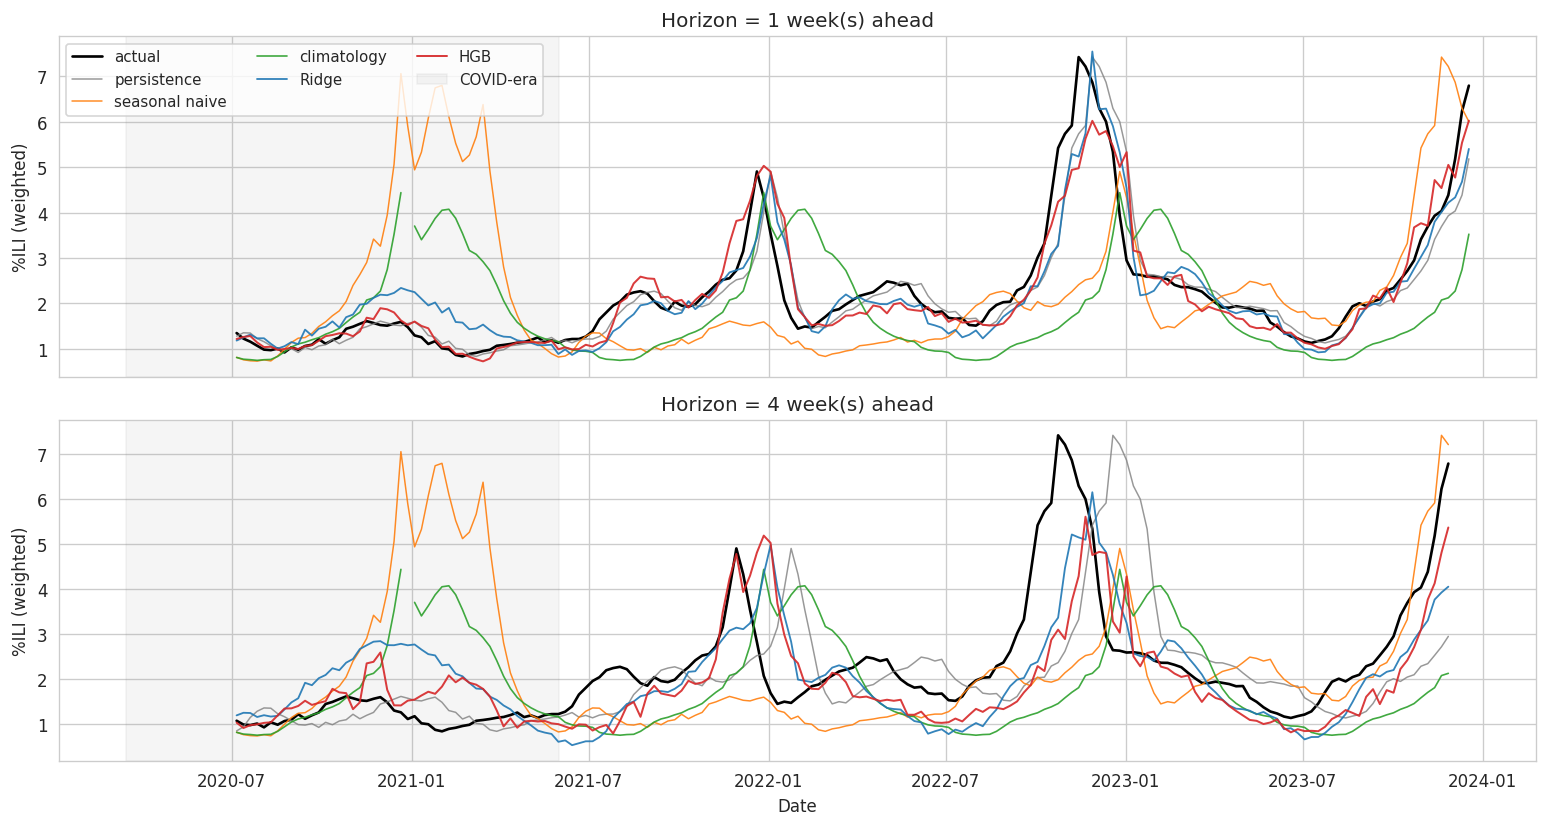

In [23]:
# ============================================================
# 3.2 Forecast trajectories on the test block
# ============================================================
# Overlay every method's h=1 and h=4 forecasts on the actual series
# across the 3-year test block. Two rows so we can see how error
# grows with horizon.
# ------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, h in zip(axes, [1, 4]):
    dates = ml_out[h]['dates']
    y_te  = ml_out[h]['y_true']
    persistence = y_all.reindex(dates - pd.Timedelta(weeks=h)).values
    snaive      = y_all.reindex(dates - pd.Timedelta(weeks=52)).values
    clim        = climatology_pred(y_all[train_mask], dates)

    ax.plot(dates, y_te,              color='black',      lw=1.6, label='actual')
    ax.plot(dates, persistence,       color='tab:gray',   lw=0.9, alpha=0.8, label='persistence')
    ax.plot(dates, snaive,            color='tab:orange', lw=0.9, alpha=0.9, label='seasonal naive')
    ax.plot(dates, clim,              color='tab:green',  lw=1.0, alpha=0.9, label='climatology')
    ax.plot(dates, ml_out[h]['ridge'],color='tab:blue',   lw=1.1, alpha=0.9, label='Ridge')
    ax.plot(dates, ml_out[h]['hgb'],  color='tab:red',    lw=1.2, alpha=0.9, label='HGB')
    ax.set_title(f'Horizon = {h} week(s) ahead')
    ax.set_ylabel('%ILI (weighted)')
    ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2021-06-01'),
               color='grey', alpha=0.08, label='COVID-era' if h == 1 else None)
    if h == 1:
        ax.legend(loc='upper left', ncol=3, fontsize=9)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


Interpretation:
Top panel: horizon = 1 week ahead, Bottom panel: horizon = 4 weeks ahead

For 1-week ahead forecast, this is easier. Tha black line is actual weighted_ili. Since HGB and Ridge roughtly follow the actual curve, they represent good predictions. Persistence prediction model is also strong because one week ahead is usually similar to the current week. During covid-19 period, the normal flu surveillance signal has been disrupted possibly by masking, school closures, covid cases not being counted as flu, so the actual ILI curve flattened. Seasonal naive performs poorly because that works only when seasonal patterns repeat. But during COVID, the pattern did not repeat. The 2022-2023 peak is hard to predict as most methods underpredict or lag behind it.

For 4-week ahead forecast, we see more delay and larger errors. This is expected because 4 weeks is far enough for the epidemic curve to rise or fall substantially. The ML models still follow the broad pattern, but peaks are hader to time, sudden rises are underpredicted, persistence model lagged the most. Seasonal naive and climatology remain poor during abnormal seasons.

### 3.2.6 Peak-period analysis

Regime thresholds from training: q33=1.16  q67=1.95

MAE by regime (h=1):
regime           high    low    mid
method                             
climatology     1.483  0.994  0.855
hgb             0.487  0.073  0.198
persistence     0.536  0.089  0.170
ridge           0.472  0.325  0.317
seasonal_naive  1.348  1.866  0.894

MAE by regime (h=4):
regime           high    low    mid
method                             
climatology     1.793  1.199  0.784
hgb             0.999  0.438  0.512
persistence     1.463  0.307  0.558
ridge           0.923  0.676  0.738
seasonal_naive  1.307  2.361  0.735


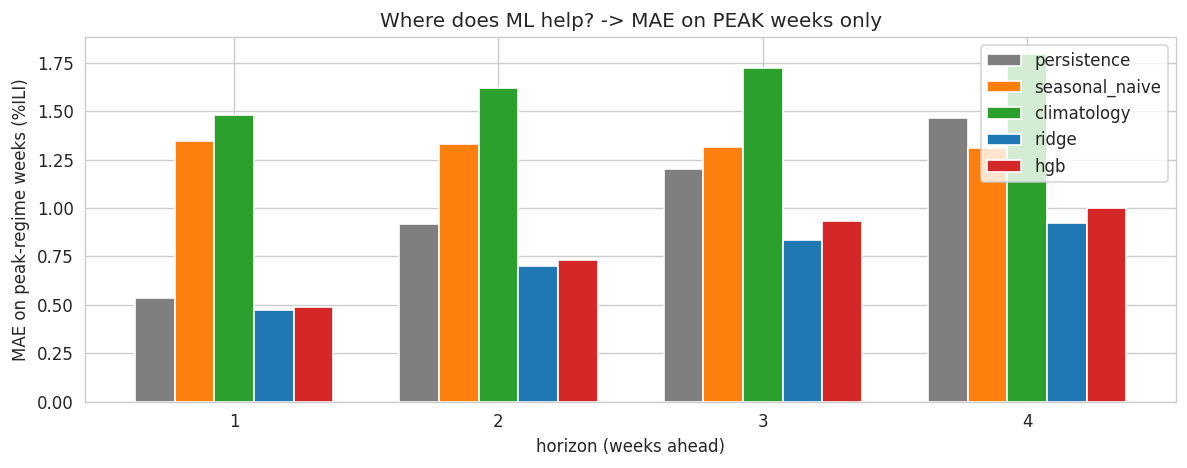

In [24]:
# ============================================================
# 3.2 Peak-period analysis: where forecasting actually matters
# ============================================================
# We ask if the models perform well during important flu peak weeks or just during easy low-ILI weeks.
# Because a model can look good overall if it performs during quiet period, but still fail during peaks.
# Average MAE conflates easy weeks (summer, ILI ~ 1%) with hard weeks (peak, ILI ~ 6-8%). Public health cares about the peak:
# timing, height, and growth phase on the rising edge. Here we recompute MAE on three regimes defined by the ACTUAL value at
# the target date, using training-set quantiles:
#   - 'low'    : y < 33rd percentile of training y   (off-season)
#   - 'mid'    : between 33rd and 67th              (shoulder)
#   - 'high'   : y >= 67th percentile               (peak weeks)
# This tells us whether ML only wins in the easy regime.
# ------------------------------------------------------------------------

q33, q67 = np.quantile(y_all[train_mask], [0.33, 0.67])
print(f"Regime thresholds from training: q33={q33:.2f}  q67={q67:.2f}")

rows = []
for h in HORIZONS:
    dates = ml_out[h]['dates']
    y_te  = ml_out[h]['y_true']
    persistence = y_all.reindex(dates - pd.Timedelta(weeks=h)).values
    snaive      = y_all.reindex(dates - pd.Timedelta(weeks=52)).values
    clim        = climatology_pred(y_all[train_mask], dates)
    preds = {'persistence': persistence, 'seasonal_naive': snaive,
             'climatology': clim, 'ridge': ml_out[h]['ridge'],
             'hgb': ml_out[h]['hgb']}
    regime = np.where(y_te < q33, 'low',
             np.where(y_te < q67, 'mid', 'high'))
    for name, pred in preds.items():
        for r in ['low', 'mid', 'high']:
            m = (regime == r) & np.isfinite(pred) & np.isfinite(y_te)
            if m.sum() == 0:
                continue
            mae = np.mean(np.abs(pred[m] - y_te[m]))
            rows.append({'horizon': h, 'method': name, 'regime': r,
                         'n': int(m.sum()), 'MAE': mae})

regime_df = pd.DataFrame(rows)
print("\nMAE by regime (h=1):")
print(regime_df[regime_df['horizon'] == 1]
      .pivot(index='method', columns='regime', values='MAE').round(3))
print("\nMAE by regime (h=4):")
print(regime_df[regime_df['horizon'] == 4]
      .pivot(index='method', columns='regime', values='MAE').round(3))

# Bar plot: peak-regime MAE only, all horizons
fig, ax = plt.subplots(figsize=(10, 4))
peak = regime_df[regime_df['regime'] == 'high']
methods = ['persistence', 'seasonal_naive', 'climatology', 'ridge', 'hgb']
colors  = ['tab:gray', 'tab:orange', 'tab:green', 'tab:blue', 'tab:red']
w = 0.15
for i, (m, c) in enumerate(zip(methods, colors)):
    sub = peak[peak['method'] == m].sort_values('horizon')
    ax.bar(sub['horizon'] + (i - 2) * w, sub['MAE'], width=w, label=m, color=c)
ax.set_xticks(HORIZONS)
ax.set_xlabel('horizon (weeks ahead)')
ax.set_ylabel('MAE on peak-regime weeks (%ILI)')
ax.set_title('Where does ML help? -> MAE on PEAK weeks only')
ax.legend()
plt.tight_layout(); plt.show()


Interpretation: The bar plot shows only high-season weeks (lower bar = better).
For h=1--MAE from HGB = 0.486, Ridge = 0.472, Persistence = 0.536--ML is slightly better than persistence. Ridge and HGB are close
For h=2, ML beats persistence more clearly
For h=3, again, ML is useful in peak weeks. Ridge is better than RGB in this analysis
For h=4, ridge is best, HGB second, and both beat persistence model.

This analysis suggest that ML helps most during peak-regime weeks, especially at longer horizons (t=4). Persistence is strong in low/off season weeks, but during high-ILI weeks and longer forecasts, Ridge and HGB reduce error compared with sample baselines.
More spefically, HGB was best overall in the earlier full-test MAE table, but **RIDGE** appears storngest for peak weeks at horizon 1,3,4. This suggests that the **simple linear lag/seasonal structure** may be more stable during high-ILI periods, while HGB performs better overall across all periods.

### 3.2.7 Walk-forward CV

In [25]:
# ============================================================
# 3.2 Walk-forward CV: is the single-split result stable?
# ============================================================
# Are the model results stable, or did they only look good because of one lucky train/test split??
# The previous evaluation use "before 2020-07" as training data and "2020-07 onward" as testing data.
# But one split can be misleading...
#
# So this step we use walk-forward validation, which retrains on an expanding window and evaluates on the next season, then slides
# forward. We use 4 folds ending in 2017, 2018, 2019, 2020 seasons.
# ------------------------------------------------------------------------
# Example of walk-forward validation:
# Fold 1:
# Train: beginning → 2017-07
# Test:  2017-07 → 2018-07
#
# Fold 2:
# Train: beginning → 2018-07
# Test:  2018-07 → 2019-07
#
# Fold 3:
# Train: beginning → 2019-07
# Test:  2019-07 → 2020-07

from sklearn.linear_model import Ridge
from sklearn.ensemble     import HistGradientBoostingRegressor
from sklearn.pipeline     import Pipeline
from sklearn.impute       import SimpleImputer
from sklearn.preprocessing import StandardScaler

fold_ends = [pd.Timestamp(f'{yr}-07-01') for yr in [2017, 2018, 2019, 2020]]
wf_rows = []

for fold_i, fold_end in enumerate(fold_ends):
    tr_mask = feat.index < fold_end
    te_mask = (feat.index >= fold_end) & (feat.index < fold_end + pd.Timedelta(weeks=52))
    if te_mask.sum() < 30:
        continue
    for h in HORIZONS:
        tgt = f'target_h{h}'
        tr_rows = feat.index[tr_mask].intersection(
            feat.dropna(subset=FEATURE_COLS + [tgt]).index)
        te_rows = feat.index[te_mask].intersection(
            feat.dropna(subset=[tgt]).index)
        if len(te_rows) < 20:
            continue
        X_tr, y_tr = feat.loc[tr_rows, FEATURE_COLS].values, feat.loc[tr_rows, tgt].values
        X_te, y_te = feat.loc[te_rows, FEATURE_COLS].values, feat.loc[te_rows, tgt].values

        ridge = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler()),
            ('reg',    Ridge(alpha=1.0, random_state=0)),
        ]).fit(X_tr, y_tr)
        hgb = HistGradientBoostingRegressor(
            max_depth=6, learning_rate=0.05, max_iter=400,
            min_samples_leaf=20, l2_regularization=1.0, random_state=0
        ).fit(X_tr, y_tr)

        pers  = y_all.reindex(te_rows - pd.Timedelta(weeks=h)).values
        snaiv = y_all.reindex(te_rows - pd.Timedelta(weeks=52)).values
        clim  = climatology_pred(y_all[tr_mask], te_rows)

        for name, pred in [('persistence', pers), ('seasonal_naive', snaiv),
                           ('climatology', clim),  ('ridge', ridge.predict(X_te)),
                           ('hgb', hgb.predict(X_te))]:
            m = np.isfinite(pred) & np.isfinite(y_te)
            mae = np.mean(np.abs(pred[m] - y_te[m]))
            wf_rows.append({'fold': fold_i, 'fold_end': fold_end.year,
                            'horizon': h, 'method': name, 'MAE': mae})

wf = pd.DataFrame(wf_rows)
print("Walk-forward MAE (mean +/- sd across 4 pre-COVID folds):\n")
summary = (wf.groupby(['horizon', 'method'])['MAE']
             .agg(['mean', 'std'])
             .round(3)
             .unstack('method'))
print(summary)


Walk-forward MAE (mean +/- sd across 4 pre-COVID folds):

               mean                                                  std  \
method  climatology    hgb persistence  ridge seasonal_naive climatology   
horizon                                                                    
1             0.781  0.349       0.408  0.378          0.967       0.267   
2             0.803  0.441       0.692  0.515          1.024       0.269   
3             0.839  0.528       0.953  0.622          1.105       0.278   
4             0.886  0.535       1.227  0.716          1.199       0.293   

                                                  
method     hgb persistence  ridge seasonal_naive  
horizon                                           
1        0.198       0.238  0.086          0.558  
2        0.162       0.388  0.101          0.530  
3        0.106       0.527  0.135          0.500  
4        0.148       0.690  0.163          0.459  


Interpretation:
For the mean MAE.
- Horizon 1: HGB is the best on average for 1-week ahead (MAE=0.349)
- Horizon 2: HGB is still the best.
- Horizon 3: HGB is best.
- Horizon 4: HGB is best. (mean MAE=0.535)
So the walk-forward result says that HGB perform best across all horizons on average.

For the standard deviation interpretation, lower std means more stable across seasons. Ridge has relatively low SD, so ridge is stable. HGB has slightly higher variability than Ridge at h=1, but still acceptable.

Walk-forward validation confirms that the HGB model's advantage is not just an artifact of the single 2020-07 test split. Across expanding-window folds, HGB achieved the lowest mean MAE at every forecast horizon. Ridge was slightly worse but more stable, while persistence degraded rapidly at longer horizons. Seasonal naive and climatology were weaker, suggesting that simple seasonal repetition was insufficient for accurate short-term ILI forecasting.


### 3.2.8 Discussion

This analysis forecasts national weekly `weighted_ili` from ILINet for 1–4 weeks ahead using temporal splits. All features were built only from information available at the forecast origin t, including lag values, rolling statistics, week-of-year seasonality, and recent changes. Targets were defined as `y_{t+h}`, and I used a direct strategy with one separate model per horizon to avoid recursive error accumulation.

**Why the holdout straddles COVID on purpose.** The main holdout starts on 2020-07-01, so the test period includes the COVID-era disruption, the weak 2021–2022 season, and the strong 2022–2023 rebound. This was a difficult but useful test because COVID broke the usual seasonal flu pattern. The low ILI curve during early COVID does not mean COVID was absent; rather, ILINet weighted %ILI is not the same as total COVID cases, and public-health measures strongly suppressed influenza transmission and changed care-seeking patterns.

**HGB wins.** Overall, HGB performed best across the full test block. It had the lowest MAE at all horizons, from 0.309 at 1 week ahead to 0.725 at 4 weeks ahead. Ridge was usually second best and was close to HGB at some horizons. As expected, forecasting error increased with horizon length because predicting 4 weeks ahead is harder than predicting 1 week ahead.

Persistence was a strong baseline at 1 week ahead because ILI changes smoothly week to week. However, it became weaker at longer horizons because it simply repeats the current value y_t and cannot anticipate future rises or declines. Seasonal naive and climatology performed poorly on the COVID-era holdout because they assume that seasonal patterns repeat. This assumption failed during the pandemic and rebound period.

**Model performance depends on seasons.** The regime analysis showed that model performance depended on the target ILI level. During low-ILI weeks, most methods performed reasonably well because the series was nearly flat. During high-ILI weeks, errors were larger and ML models were more useful. HGB was best overall, but Ridge was very competitive during peak-regime weeks, suggesting that a simpler linear model may still be useful when interpretability and stability matter.

**Walk-forward CV (pre-COVID seasons 2016-17 through 2019-20).** Walk-forward validation supported the main result. Across expanding-window folds, HGB had the lowest mean MAE at every horizon, while Ridge was close behind and more stable across folds. This suggests that HGB's advantage was not only due to one lucky train-test split. One caveat is that the fold starting in 2020-07 includes the COVID-disrupted season, so the walk-forward analysis is not entirely pre-COVID.

Several limitations remain, for example,
1. The analysis used finalized ILINet data, while real-time ILINet values may be revised.
2. The models used only past ILI and calendar features; external signals such as google search trends, EHR data, school absence, or pharmacy data could improve short-term forecasting.
3. The analysis used **point** forecasts only, whereas public-health forecasting usually benefits from prediction intervals.

In summary, HGB was the best overall model for 1–4 week national weighted ILI forecasting, especially at longer horizons. Ridge was a strong, simpler alternative. Persistence was hard to beat at 1 week ahead but weaker at longer horizons, while seasonal naive and climatology were fragile during the COVID-era structural break.
